# 321 — Repeated-split ZeBRA + genomics with leakage-free isotonic calibration

This notebook is the calibrated successor to `32_COMBINED_CLASSIFIERS.ipynb`.

It preserves the **exact cohort definition used by notebook 32**:

1. start from `ILD_TOP_DRIVERS_DATA.csv`;
2. left-merge the adjudicated target table;
3. convert the target to numeric;
4. assign missing target values to `0`;
5. left-merge ZeBRA `predicted_risk`;
6. retain rows with non-missing `predicted_risk`;
7. use repeated stratified 40% outer train / 60% untouched outer test splits.

For every split the notebook evaluates:

- raw ZeBRA;
- isotonic-calibrated ZeBRA;
- raw genomic LightGBM;
- isotonic-calibrated genomic LightGBM;
- raw combined ZeBRA + genomics LightGBM;
- isotonic-calibrated combined LightGBM.

## Calibration design

Calibration is performed **without using the outer test set**.

### ZeBRA

ZeBRA is already a fixed external score. Therefore, for each repeat:

- fit isotonic regression using outer-training `predicted_risk` and labels;
- apply that calibrator to the outer-test ZeBRA scores.

### Learned genomic and combined LightGBM models

Using predictions from the same patients used to fit LightGBM would give an optimistic calibrator.
Therefore, after hyperparameter selection:

1. generate out-of-fold predictions across the outer-training patients;
2. fit the isotonic calibrator to those out-of-fold predictions;
3. refit the final LightGBM on the complete outer-training set;
4. predict the untouched outer test;
5. apply the isotonic calibrator to those outer-test predictions.

The isotonic implementation follows the calibration machinery already present in `zedstat`,
including prevalence weights from `zedstat.calibration.make_prevalence_weights`.
`zedstat.calibration_intercept_slope` and `zedstat.calibration_table` are then used to assess
both raw and calibrated probabilities.

## Primary fair calibration comparison

The key probability-performance comparison is now:

**isotonic-calibrated combined model vs isotonic-calibrated ZeBRA**

rather than combined probabilities vs uncalibrated ZeBRA scores.

AUC is reported for both raw and calibrated scores. Because isotonic regression is monotone
but creates ties, small AUC changes after calibration can occur; discrimination should primarily
be interpreted from the raw score AUC.

In [1]:
import os
import json
import secrets
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap

from lightgbm import LGBMClassifier
from sklearn.model_selection import train_test_split, StratifiedKFold, ParameterSampler
from sklearn.isotonic import IsotonicRegression
from sklearn.metrics import roc_auc_score, roc_curve, average_precision_score

from zedstat import zedstat
from zedstat import calibration

from tqdm.auto import tqdm

warnings.filterwarnings("ignore")
%matplotlib inline

N_REPEATS = 30
TRAIN_SIZE = 0.40
INNER_CV_FOLDS = 3
N_PARAM_TRIALS = 12

MAX_SHAP_PATIENTS = 2000
N_SHAP_BOOT = 1000
PARTIAL_AUC_MAX_FPR = 0.05

# ------------------------------------------------------------------
# zedstat performance / calibration controls
# ------------------------------------------------------------------
ZEDSTAT_ALPHA = 0.05
ZEDSTAT_ORDER = 3
ZEDSTAT_STEPS = 1000
ZEDSTAT_SMOOTH_STEP = 0.001
ZEDSTAT_PRECISION = 3
ZEDSTAT_LR_FPR_FLOOR = 0.001
ZEDSTAT_CALIBRATION_BINS = 10

# None => use the observed prevalence in each held-out outer-test split.
# Set to a deployment prevalence if PPV/NPV should be standardized externally.
ZEDSTAT_TARGET_PREVALENCE = None

# None => calibrate to the prevalence observed in each outer-training set.
# Set to an external deployment prevalence if desired.
ISOTONIC_TARGET_PREVALENCE = None

# Standardized operating points extracted from the full zedstat table.
ZEDSTAT_OPERATING_FPRS = [0.001, 0.005, 0.01, 0.02, 0.05, 0.10]

BASE_DATA_FILE = "ILD_TOP_DRIVERS_DATA.csv"
TARGET_FILE = "REPHENOTYPES FOR IC.csv"
PRED_FILE = "PREDICTIONS_104W_PRED_WINDOW.parquet"

ROOT_OUT = Path("./RESULTS/321_REPEATED_SPLITS_ISOTONIC")
ROOT_OUT.mkdir(parents=True, exist_ok=True)

print("Train fraction:", TRAIN_SIZE)
print("Test fraction:", 1 - TRAIN_SIZE)
print("Repeats:", N_REPEATS)
print("zedstat module:", zedstat.__file__)
print("zedstat calibration module:", calibration.__file__)

print("Isotonic target prevalence:", ISOTONIC_TARGET_PREVALENCE)


Train fraction: 0.4
Test fraction: 0.6
Repeats: 30
zedstat module: /home/ishanu/.local/lib/python3.12/site-packages/zedstat/zedstat.py
zedstat calibration module: /home/ishanu/.local/lib/python3.12/site-packages/zedstat/calibration.py
Isotonic target prevalence: None


## Helper functions

In [2]:
def raw_partial_auc(y_true, score, max_fpr=0.05):
    fpr, tpr, _ = roc_curve(y_true, score, drop_intermediate=False)
    keep = fpr < max_fpr
    fk, tk = fpr[keep], tpr[keep]
    t_at = np.interp(max_fpr, fpr, tpr)
    fk = np.r_[fk, max_fpr]
    tk = np.r_[tk, t_at]
    return float(np.trapz(tk, fk))


def auc_record(target_name, repeat, split_seed, model_name, y_true, score):
    return {
        "target_name": target_name,
        "repeat": repeat,
        "split_seed": int(split_seed),
        "model": model_name,
        "n_test": int(len(y_true)),
        "n_pos_test": int(np.asarray(y_true).sum()),
        "auc": float(roc_auc_score(y_true, score)),
        "partial_auc_fpr_0_05_raw": raw_partial_auc(
            y_true, score, PARTIAL_AUC_MAX_FPR
        ),
        "average_precision": float(
            average_precision_score(y_true, score)
        ),
    }


def parameter_space():
    return {
        "n_estimators": [50, 100, 200, 400, 700],
        "learning_rate": [0.01, 0.03, 0.05, 0.08, 0.12],
        "num_leaves": [7, 15, 31, 63, 127],
        "max_depth": [-1, 3, 5, 7, 10, 14],
        "min_child_samples": [10, 20, 40, 80, 150],
        "subsample": [0.60, 0.75, 0.90, 1.0],
        "colsample_bytree": [0.40, 0.60, 0.80, 1.0],
        "reg_alpha": [0.0, 0.01, 0.10, 0.50, 1.0],
        "reg_lambda": [0.0, 0.10, 0.50, 1.0, 5.0],
        "min_split_gain": [0.0, 0.01, 0.10, 0.50],
        "max_bin": [63, 127, 255, 511],
    }


def fit_lgbm_inner_cv(X, y, param_seed, cv_seed, model_seed):
    X = X.reset_index(drop=True)
    y = np.asarray(y).astype(int)

    cv = StratifiedKFold(
        n_splits=INNER_CV_FOLDS,
        shuffle=True,
        random_state=int(cv_seed),
    )
    folds = list(cv.split(X, y))

    trials = ParameterSampler(
        parameter_space(),
        n_iter=N_PARAM_TRIALS,
        random_state=int(param_seed),
    )

    best_auc = -np.inf
    best_params = None

    for params in trials:
        fold_aucs = []

        for fi, (tr, va) in enumerate(folds):
            yy = y[tr]
            n_pos = max(int((yy == 1).sum()), 1)
            n_neg = max(int((yy == 0).sum()), 1)
            spw = n_neg / n_pos

            m = LGBMClassifier(
                **params,
                objective="binary",
                scale_pos_weight=spw,
                subsample_freq=1,
                n_jobs=-1,
                random_state=(int(model_seed) + fi + 1) % (2**31 - 1),
                verbosity=-1,
            )
            m.fit(X.iloc[tr], yy)
            p = m.predict_proba(X.iloc[va])[:, 1]
            fold_aucs.append(roc_auc_score(y[va], p))

        cv_auc = float(np.mean(fold_aucs))

        if cv_auc > best_auc:
            best_auc = cv_auc
            best_params = dict(params)

    n_pos = max(int((y == 1).sum()), 1)
    n_neg = max(int((y == 0).sum()), 1)

    final = LGBMClassifier(
        **best_params,
        objective="binary",
        scale_pos_weight=n_neg / n_pos,
        subsample_freq=1,
        n_jobs=-1,
        random_state=int(model_seed),
        verbosity=-1,
    )
    final.fit(X, y)

    return final, best_params, best_auc


def positive_class_shap(model, X):
    exp = shap.TreeExplainer(model)

    try:
        v = exp.shap_values(X, check_additivity=False)
    except TypeError:
        v = exp.shap_values(X)

    if isinstance(v, list):
        v = v[1] if len(v) > 1 else v[0]

    v = np.asarray(v)

    if v.ndim == 3:
        if v.shape[-1] == 2:
            v = v[:, :, 1]
        elif v.shape[0] == 2:
            v = v[1]

    if v.shape != X.shape:
        raise ValueError(f"Unexpected SHAP shape {v.shape}; X shape {X.shape}")

    return v


def split_shap(model, X_test, target, repeat, split_seed, model_name):
    sample_seed = secrets.randbits(31)
    Xs = X_test.sample(
        n=min(MAX_SHAP_PATIENTS, len(X_test)),
        random_state=sample_seed,
    )
    v = positive_class_shap(model, Xs)

    return pd.DataFrame({
        "target_name": target,
        "repeat": repeat,
        "split_seed": int(split_seed),
        "model": model_name,
        "feature": Xs.columns,
        "mean_abs_shap": np.abs(v).mean(axis=0),
        "n_shap_patients": len(Xs),
    })


def auc_summary(df):
    return (
        df.groupby(["target_name", "model"])["auc"]
        .agg(
            n_repeats="size",
            mean="mean",
            sd="std",
            median="median",
            min="min",
            max="max",
        )
        .reset_index()
    )


def shap_summary(df):
    rng = np.random.default_rng()
    rows = []

    for (target, model, feature), sub in df.groupby(
        ["target_name", "model", "feature"], sort=False
    ):
        x = sub["mean_abs_shap"].dropna().to_numpy(float)
        if len(x) == 0:
            continue

        boot_mean = np.empty(N_SHAP_BOOT)
        boot_max = np.empty(N_SHAP_BOOT)

        for b in range(N_SHAP_BOOT):
            xb = rng.choice(x, len(x), replace=True)
            boot_mean[b] = xb.mean()
            boot_max[b] = xb.max()

        rows.append({
            "target_name": target,
            "model": model,
            "feature": feature,
            "n_splits": len(x),
            "mean_importance": x.mean(),
            "median_importance": np.median(x),
            "max_importance": x.max(),
            "empirical_q025": np.quantile(x, 0.025),
            "empirical_q975": np.quantile(x, 0.975),
            "bootstrap_mean_ci_low": np.quantile(boot_mean, 0.025),
            "bootstrap_mean_ci_high": np.quantile(boot_mean, 0.975),
            "bootstrap_max_ci_low": np.quantile(boot_max, 0.025),
            "bootstrap_max_ci_high": np.quantile(boot_max, 0.975),
        })

    return pd.DataFrame(rows)

# =====================================================================
# zedstat evaluation helpers
# =====================================================================

def zedstat_evaluate_score(
    y_true,
    score,
    target_name,
    repeat,
    split_seed,
    model_name,
):
    """
    Evaluate one held-out score vector using zedstat.

    Returns
    -------
    summary : dict
        One-row model/split summary including AUC + CI and calibration.
    perf_df : pandas.DataFrame
        Full threshold-level zedstat operating-characteristics table,
        including analytic bounds.
    cal_df : pandas.DataFrame
        zedstat calibration/reliability table.
    """
    y_true = np.asarray(y_true).astype(int)
    score = np.asarray(score, dtype=float)

    valid = np.isfinite(score) & np.isfinite(y_true)
    y_true = y_true[valid]
    score = score[valid]

    if np.unique(y_true).size < 2:
        raise ValueError(
            f"{target_name} / {model_name} / repeat {repeat}: "
            "both classes are required for zedstat evaluation."
        )

    eval_df = pd.DataFrame({
        "score": score,
        "target": y_true,
    })

    observed_prevalence = float(y_true.mean())
    prevalence_for_metrics = (
        observed_prevalence
        if ZEDSTAT_TARGET_PREVALENCE is None
        else float(ZEDSTAT_TARGET_PREVALENCE)
    )

    # --------------------------------------------------------------
    # Build ROC using zedstat and compute all operating measures.
    # --------------------------------------------------------------
    roc_df, total_samples, positive_samples = zedstat.genroc(
        eval_df,
        risk="score",
        target="target",
        steps=ZEDSTAT_STEPS,
        TARGET=[1],
    )

    zt = zedstat.processRoc(
        df=roc_df,
        order=ZEDSTAT_ORDER,
        total_samples=total_samples,
        positive_samples=positive_samples,
        alpha=ZEDSTAT_ALPHA,
        prevalence=prevalence_for_metrics,
        lr_fpr_floor=ZEDSTAT_LR_FPR_FLOOR,
    )

    # Keep empirical shape: do not convexify.
    zt.smooth(
        STEP=ZEDSTAT_SMOOTH_STEP,
        convexify=False,
    )
    zt.allmeasures(
        prevalence=prevalence_for_metrics,
        interpolate=True,
    )
    zt.usample(
        precision=ZEDSTAT_PRECISION,
    )
    zt.getBounds(
        total_samples=total_samples,
        positive_samples=positive_samples,
        alpha=ZEDSTAT_ALPHA,
        prevalence=prevalence_for_metrics,
    )

    nominal = zt.get()

    perf_df = (
        nominal
        .join(
            zt.df_lim["U"],
            rsuffix="_upper",
        )
        .join(
            zt.df_lim["L"],
            rsuffix="_lower",
        )
    )

    # zedstat may return FPR both as the dataframe index name and as
    # a regular column. In that case reset_index() would try to insert
    # a second "fpr" column and pandas raises:
    #   ValueError: cannot insert fpr, already exists
    #
    # Preserve the explicit zedstat fpr column and discard only the
    # redundant index representation.
    if (
        perf_df.index.name is not None
        and perf_df.index.name in perf_df.columns
    ):
        perf_df = perf_df.reset_index(drop=True)
    else:
        perf_df = perf_df.reset_index()

    if "fpr" not in perf_df.columns:
        raise RuntimeError(
            "zedstat performance table unexpectedly lacks an fpr column."
        )

    if perf_df.columns.duplicated().any():
        dup_cols = perf_df.columns[
            perf_df.columns.duplicated()
        ].tolist()
        raise RuntimeError(
            f"zedstat performance table contains duplicate columns: {dup_cols}"
        )

    # zedstat AUC and analytic Hanley-McNeil confidence interval.
    # zedstat returns (nominal, upper, lower).
    auc_nominal, auc_upper, auc_lower = zt.auc(
        total_samples=total_samples,
        positive_samples=positive_samples,
        alpha=ZEDSTAT_ALPHA,
        bootstrap=False,
    )

    # --------------------------------------------------------------
    # zedstat calibration assessment of the raw held-out probabilities.
    # --------------------------------------------------------------
    score_is_probability = bool(
        np.all((score >= 0.0) & (score <= 1.0))
    )

    if score_is_probability:
        cal_intercept, cal_slope = (
            calibration.calibration_intercept_slope(
                y_true,
                score,
            )
        )

        cal_df = calibration.calibration_table(
            prob=score,
            y=y_true,
            n_bins=ZEDSTAT_CALIBRATION_BINS,
            alpha=ZEDSTAT_ALPHA,
        )

        brier = float(
            np.mean(
                (score - y_true) ** 2
            )
        )

        cal_abs_error = (
            cal_df["obs_rate"]
            - cal_df["mean_pred"]
        ).abs()

        ece = float(
            np.average(
                cal_abs_error,
                weights=cal_df["n"],
            )
        )
        max_cal_error = float(
            cal_abs_error.max()
        )
        mean_predicted_risk = float(
            score.mean()
        )
        observed_to_expected = (
            observed_prevalence / mean_predicted_risk
            if mean_predicted_risk > 0
            else np.nan
        )
    else:
        cal_intercept = np.nan
        cal_slope = np.nan
        brier = np.nan
        ece = np.nan
        max_cal_error = np.nan
        mean_predicted_risk = np.nan
        observed_to_expected = np.nan
        cal_df = pd.DataFrame()

    # Annotate every threshold row so all splits/models can be concatenated.
    perf_df.insert(0, "model", model_name)
    perf_df.insert(0, "split_seed", int(split_seed))
    perf_df.insert(0, "repeat", int(repeat))
    perf_df.insert(0, "target_name", target_name)

    if "tpr" in perf_df.columns:
        perf_df["sensitivity"] = perf_df["tpr"]
    if "fpr" in perf_df.columns:
        perf_df["specificity"] = 1.0 - perf_df["fpr"]

    if len(cal_df):
        cal_df = cal_df.copy()
        cal_df.insert(0, "model", model_name)
        cal_df.insert(0, "split_seed", int(split_seed))
        cal_df.insert(0, "repeat", int(repeat))
        cal_df.insert(0, "target_name", target_name)

    summary = {
        "target_name": target_name,
        "repeat": int(repeat),
        "split_seed": int(split_seed),
        "model": model_name,
        "n_test": int(total_samples),
        "n_positive": int(positive_samples),
        "n_negative": int(total_samples - positive_samples),
        "observed_prevalence": observed_prevalence,
        "performance_prevalence": prevalence_for_metrics,

        "zedstat_auc": float(auc_nominal),
        "zedstat_auc_ci_low": float(auc_lower),
        "zedstat_auc_ci_high": float(auc_upper),

        "brier_score": brier,
        "calibration_intercept": float(cal_intercept)
            if np.isfinite(cal_intercept) else np.nan,
        "calibration_slope": float(cal_slope)
            if np.isfinite(cal_slope) else np.nan,
        "expected_calibration_error": ece,
        "max_calibration_error": max_cal_error,
        "mean_predicted_risk": mean_predicted_risk,
        "observed_to_expected_ratio": observed_to_expected,
    }

    return summary, perf_df, cal_df


def extract_zedstat_operating_points(
    perf_df,
    requested_fprs=ZEDSTAT_OPERATING_FPRS,
):
    """
    Extract nearest rows from a full zedstat operating table at
    standardized FPR values.
    """
    if len(perf_df) == 0:
        return pd.DataFrame()

    if "fpr" not in perf_df.columns:
        raise ValueError(
            "zedstat performance table does not contain an fpr column."
        )

    rows = []

    for requested_fpr in requested_fprs:
        distance = (
            perf_df["fpr"].astype(float)
            - float(requested_fpr)
        ).abs()

        row = perf_df.loc[
            distance.idxmin()
        ].copy()

        row["requested_fpr"] = float(
            requested_fpr
        )
        row["fpr_distance"] = float(
            distance.min()
        )

        rows.append(row)

    return pd.DataFrame(rows)


def summarize_repeated_metric(
    df,
    metric_columns,
    group_columns=("target_name", "model"),
):
    """
    Distribution summary over repeated outer splits.
    """
    rows = []

    for keys, sub in df.groupby(
        list(group_columns),
        sort=False,
    ):
        if not isinstance(keys, tuple):
            keys = (keys,)

        base = dict(
            zip(
                group_columns,
                keys,
            )
        )

        for metric in metric_columns:
            if metric not in sub.columns:
                continue

            x = pd.to_numeric(
                sub[metric],
                errors="coerce",
            ).dropna().to_numpy(dtype=float)

            if len(x) == 0:
                continue

            rows.append({
                **base,
                "metric": metric,
                "n_repeats": int(len(x)),
                "mean": float(np.mean(x)),
                "sd": float(np.std(x, ddof=1))
                    if len(x) > 1 else np.nan,
                "median": float(np.median(x)),
                "q025": float(np.quantile(x, 0.025)),
                "q975": float(np.quantile(x, 0.975)),
                "min": float(np.min(x)),
                "max": float(np.max(x)),
            })

    return pd.DataFrame(rows)


# =====================================================================
# Leakage-free isotonic calibration helpers
# =====================================================================

def fit_zedstat_isotonic(
    raw_score,
    y,
    target_prevalence=ISOTONIC_TARGET_PREVALENCE,
):
    """
    Fit an isotonic calibrator using zedstat's prevalence-weighting logic.

    The caller is responsible for ensuring these scores come only from
    calibration/training data, never from the outer test set.
    """
    raw_score = np.asarray(raw_score, dtype=float)
    y = np.asarray(y, dtype=int)

    valid = np.isfinite(raw_score) & np.isfinite(y)
    raw_score = raw_score[valid]
    y = y[valid]

    if np.unique(y).size < 2:
        raise ValueError("Both classes are required for isotonic calibration.")

    weights = calibration.make_prevalence_weights(
        y,
        target_prevalence=target_prevalence,
    )

    iso = IsotonicRegression(
        y_min=0.0,
        y_max=1.0,
        out_of_bounds="clip",
    )

    iso.fit(
        raw_score,
        y,
        sample_weight=weights,
    )

    return iso


def lgbm_oof_predictions(
    X,
    y,
    best_params,
    cv_seed,
    model_seed,
):
    """
    Produce one out-of-fold probability for every outer-training patient
    using the already-selected LightGBM hyperparameters.

    These OOF probabilities are used only to fit the isotonic calibrator.
    No outer-test information is used.
    """
    X = X.reset_index(drop=True)
    y = np.asarray(y, dtype=int)

    cv = StratifiedKFold(
        n_splits=INNER_CV_FOLDS,
        shuffle=True,
        random_state=int(cv_seed),
    )

    oof = np.full(
        len(y),
        np.nan,
        dtype=float,
    )

    for fold_id, (tr, va) in enumerate(
        cv.split(X, y)
    ):
        y_train_fold = y[tr]

        n_pos = max(
            int((y_train_fold == 1).sum()),
            1,
        )
        n_neg = max(
            int((y_train_fold == 0).sum()),
            1,
        )

        scale_pos_weight = (
            n_neg / n_pos
        )

        fold_seed = (
            int(model_seed)
            + 1009 * (fold_id + 1)
        ) % (2**31 - 1)

        model = LGBMClassifier(
            **best_params,
            objective="binary",
            scale_pos_weight=scale_pos_weight,
            subsample_freq=1,
            n_jobs=-1,
            random_state=fold_seed,
            verbosity=-1,
        )

        model.fit(
            X.iloc[tr],
            y_train_fold,
        )

        oof[va] = model.predict_proba(
            X.iloc[va]
        )[:, 1]

    if np.isnan(oof).any():
        raise RuntimeError(
            "OOF prediction generation left missing values."
        )

    return oof


def calibration_training_audit(
    raw_score,
    calibrated_score,
    y,
):
    """
    Small audit record for the data used to fit a calibrator.
    """
    raw_score = np.asarray(raw_score, dtype=float)
    calibrated_score = np.asarray(calibrated_score, dtype=float)
    y = np.asarray(y, dtype=int)

    return {
        "n_calibration": int(len(y)),
        "n_positive_calibration": int(y.sum()),
        "raw_auc_calibration_data": float(
            roc_auc_score(y, raw_score)
        ),
        "calibrated_auc_calibration_data": float(
            roc_auc_score(y, calibrated_score)
        ),
        "raw_brier_calibration_data": float(
            np.mean((raw_score - y) ** 2)
        ),
        "calibrated_brier_calibration_data": float(
            np.mean((calibrated_score - y) ** 2)
        ),
        "n_unique_raw_scores": int(
            np.unique(raw_score).size
        ),
        "n_unique_calibrated_scores": int(
            np.unique(calibrated_score).size
        ),
    }


## Load the same inputs as notebook 03

In [3]:
BASE_DATA = pd.read_csv(BASE_DATA_FILE).drop(
    columns=["target"], errors="ignore"
)

NEW_TARGETS = (
    pd.read_csv(TARGET_FILE)
    .replace({"N": 0, "Y": 1, "y": 1, "n": 0, "na": np.nan})
    .rename(columns={"arb_person_id": "patient_id"})
)

PREDS = pd.read_parquet(PRED_FILE)

TARGET_NAMES = [
    c for c in NEW_TARGETS.columns
    if c != "patient_id"
]

print("BASE_DATA rows:", len(BASE_DATA))
print("Prediction rows:", len(PREDS))
print("Prediction unique patients:", PREDS["patient_id"].nunique())
print("Prediction duplicate rows beyond first:", PREDS["patient_id"].duplicated().sum())

print("\nTargets:")
for t in TARGET_NAMES:
    print(" -", t)

BASE_DATA rows: 19651
Prediction rows: 19519
Prediction unique patients: 12825
Prediction duplicate rows beyond first: 6693

Targets:
 - FILD or FILA ADJUDICATED
 - NONFIBROTIC ILD ADJUDICATED
 - NON FIBROTIC ILA ADJUDICATED


## Verify exact notebook-03 target construction

The critical lines below intentionally mirror notebook 03:

```python
DATA["target"] = pd.to_numeric(DATA["target"], errors="coerce").fillna(0).astype(int)
DATA = DATA[DATA["predicted_risk"].notnull()].copy()
```

The sanity split uses `random_state=1321` and should reproduce the ZeBRA result from 03.

In [4]:
SANITY = []

for TARGET_NAME in TARGET_NAMES:

    DATA = (
        BASE_DATA
        .merge(
            NEW_TARGETS[["patient_id", TARGET_NAME]].rename(
                columns={TARGET_NAME: "target"}
            ),
            on="patient_id",
            how="left",
        )
        .merge(
            PREDS[["patient_id", "predicted_risk"]],
            on="patient_id",
            how="left",
        )
    )

    # EXACT NOTEBOOK-03 TARGET LOGIC
    DATA["target"] = (
        pd.to_numeric(DATA["target"], errors="coerce")
        .fillna(0)
        .astype(int)
    )

    # EXACT NOTEBOOK-03 FILTER
    DATA = DATA[
        DATA["predicted_risk"].notnull()
    ].copy()

    X = DATA.drop(columns=["patient_id", "target"])
    y = DATA["target"]

    X_train, X_val, y_train, y_val = train_test_split(
        X,
        y,
        train_size=0.40,
        stratify=y,
        random_state=1321,
    )

    auc03 = roc_auc_score(
        y_val,
        X_val["predicted_risk"],
    )

    SANITY.append({
        "target_name": TARGET_NAME,
        "n_total": len(DATA),
        "n_positive_total": int(y.sum()),
        "n_validation": len(y_val),
        "n_positive_validation": int(y_val.sum()),
        "zebra_auc_exact_03_split": float(auc03),
    })

SANITY = pd.DataFrame(SANITY)
SANITY.to_csv(
    ROOT_OUT / "sanity_exact_03_target_logic.csv",
    index=False,
)

display(SANITY)

,target_name,n_total,n_positive_total,n_validation,n_positive_validation,zebra_auc_exact_03_split
0,FILD or FILA ADJUDICATED,12825,254,7695,152,0.804147
1,NONFIBROTIC ILD ADJUDICATED,12825,27,7695,16,0.837902
2,NON FIBROTIC ILA ADJUDICATED,12825,74,7695,44,0.809235


## Repeated randomized outer splits with leakage-free calibration

Every repeat uses a fresh stratified 40% outer-training / 60% outer-test split.

For each repeat:

- ZeBRA raw is evaluated directly.
- ZeBRA isotonic is fit on the outer-training ZeBRA scores only.
- Genomic and combined LightGBM hyperparameters are selected within outer training.
- Out-of-fold outer-training predictions are generated for each learned model.
- Separate isotonic calibrators are fit on those OOF predictions.
- Final LightGBM models predict the untouched outer test.
- The fitted isotonic mappings are applied to those test predictions.
- zedstat evaluates raw and calibrated variants on exactly the same test patients.

The outer test set is never used to fit either a classifier or a calibrator.

In [5]:
ALL_AUC = []
ALL_SHAP = []
ALL_PARAMS = []

ALL_ZEDSTAT_SUMMARY = []
ALL_ZEDSTAT_PERFORMANCE = []
ALL_ZEDSTAT_CALIBRATION = []
ALL_ZEDSTAT_OPERATING_POINTS = []

ALL_CALIBRATION_AUDIT = []

for target_index, TARGET_NAME in enumerate(
    TARGET_NAMES,
    start=1,
):

    print()
    print("=" * 110)
    print(
        f"TARGET {target_index}/{len(TARGET_NAMES)}: "
        f"{TARGET_NAME}"
    )
    print("=" * 110)

    TDIR = ROOT_OUT / TARGET_NAME
    TDIR.mkdir(
        parents=True,
        exist_ok=True,
    )

    DATA = (
        BASE_DATA
        .merge(
            NEW_TARGETS[
                ["patient_id", TARGET_NAME]
            ].rename(
                columns={
                    TARGET_NAME: "target"
                }
            ),
            on="patient_id",
            how="left",
        )
        .merge(
            PREDS[
                ["patient_id", "predicted_risk"]
            ],
            on="patient_id",
            how="left",
        )
    )

    # EXACT notebook-32 target logic
    DATA["target"] = (
        pd.to_numeric(
            DATA["target"],
            errors="coerce",
        )
        .fillna(0)
        .astype(int)
    )

    # EXACT notebook-32 availability filter
    DATA = DATA[
        DATA["predicted_risk"].notnull()
    ].copy()

    X_combined = DATA.drop(
        columns=[
            "patient_id",
            "target",
        ]
    )

    X_genomic = X_combined.drop(
        columns=[
            "predicted_risk"
        ]
    )

    y = DATA[
        "target"
    ].to_numpy()

    print(
        f"N={len(DATA):,}; "
        f"positives={y.sum():,}; "
        f"genomic features={X_genomic.shape[1]:,}"
    )

    target_auc = []
    target_shap_frames = []

    repeat_bar = tqdm(
        range(
            1,
            N_REPEATS + 1,
        ),
        desc=f"{TARGET_NAME}: repeats",
    )

    for repeat in repeat_bar:

        split_seed = secrets.randbits(31)
        cv_seed = secrets.randbits(31)

        train_idx, test_idx = train_test_split(
            np.arange(len(DATA)),
            train_size=TRAIN_SIZE,
            stratify=y,
            random_state=split_seed,
        )

        y_train = y[train_idx]
        y_test = y[test_idx]

        Xg_train = X_genomic.iloc[
            train_idx
        ].copy()
        Xg_test = X_genomic.iloc[
            test_idx
        ].copy()

        Xc_train = X_combined.iloc[
            train_idx
        ].copy()
        Xc_test = X_combined.iloc[
            test_idx
        ].copy()

        # ======================================================
        # 1. ZeBRA: raw score + isotonic calibration
        # ======================================================

        zebra_train_raw = Xc_train[
            "predicted_risk"
        ].to_numpy(dtype=float)

        zebra_test_raw = Xc_test[
            "predicted_risk"
        ].to_numpy(dtype=float)

        zebra_iso = fit_zedstat_isotonic(
            zebra_train_raw,
            y_train,
        )

        zebra_train_cal = zebra_iso.predict(
            zebra_train_raw
        )

        zebra_test_cal = zebra_iso.predict(
            zebra_test_raw
        )

        zebra_audit = calibration_training_audit(
            zebra_train_raw,
            zebra_train_cal,
            y_train,
        )

        ALL_CALIBRATION_AUDIT.append({
            "target_name": TARGET_NAME,
            "repeat": repeat,
            "split_seed": int(split_seed),
            "model": "zebra",
            "calibration_source": "outer_train_fixed_score",
            **zebra_audit,
        })

        # ======================================================
        # 2. Genomic-only LightGBM
        # ======================================================

        genomic_model_seed = secrets.randbits(31)

        genomic_model, genomic_params, genomic_cv_auc = (
            fit_lgbm_inner_cv(
                Xg_train,
                y_train,
                param_seed=secrets.randbits(31),
                cv_seed=cv_seed,
                model_seed=genomic_model_seed,
            )
        )

        genomic_test_raw = genomic_model.predict_proba(
            Xg_test
        )[:, 1]

        genomic_oof = lgbm_oof_predictions(
            Xg_train,
            y_train,
            best_params=genomic_params,
            cv_seed=cv_seed,
            model_seed=genomic_model_seed,
        )

        genomic_iso = fit_zedstat_isotonic(
            genomic_oof,
            y_train,
        )

        genomic_oof_cal = genomic_iso.predict(
            genomic_oof
        )

        genomic_test_cal = genomic_iso.predict(
            genomic_test_raw
        )

        genomic_audit = calibration_training_audit(
            genomic_oof,
            genomic_oof_cal,
            y_train,
        )

        ALL_CALIBRATION_AUDIT.append({
            "target_name": TARGET_NAME,
            "repeat": repeat,
            "split_seed": int(split_seed),
            "model": "genomic",
            "calibration_source": "outer_train_oof_predictions",
            **genomic_audit,
        })

        # ======================================================
        # 3. Combined ZeBRA + genomics LightGBM
        # ======================================================

        combined_model_seed = secrets.randbits(31)

        combined_model, combined_params, combined_cv_auc = (
            fit_lgbm_inner_cv(
                Xc_train,
                y_train,
                param_seed=secrets.randbits(31),
                cv_seed=cv_seed,
                model_seed=combined_model_seed,
            )
        )

        combined_test_raw = combined_model.predict_proba(
            Xc_test
        )[:, 1]

        combined_oof = lgbm_oof_predictions(
            Xc_train,
            y_train,
            best_params=combined_params,
            cv_seed=cv_seed,
            model_seed=combined_model_seed,
        )

        combined_iso = fit_zedstat_isotonic(
            combined_oof,
            y_train,
        )

        combined_oof_cal = combined_iso.predict(
            combined_oof
        )

        combined_test_cal = combined_iso.predict(
            combined_test_raw
        )

        combined_audit = calibration_training_audit(
            combined_oof,
            combined_oof_cal,
            y_train,
        )

        ALL_CALIBRATION_AUDIT.append({
            "target_name": TARGET_NAME,
            "repeat": repeat,
            "split_seed": int(split_seed),
            "model": "combined",
            "calibration_source": "outer_train_oof_predictions",
            **combined_audit,
        })

        # ======================================================
        # Evaluate all raw + calibrated variants using zedstat
        # ======================================================

        model_scores = {
            "zebra_raw": zebra_test_raw,
            "zebra_isotonic": zebra_test_cal,
            "genomic_raw": genomic_test_raw,
            "genomic_isotonic": genomic_test_cal,
            "combined_raw": combined_test_raw,
            "combined_isotonic": combined_test_cal,
        }

        repeat_zedstat_summary = []
        repeat_zedstat_perf = []
        repeat_zedstat_cal = []
        repeat_zedstat_ops = []

        for model_name, score in model_scores.items():

            z_summary, z_perf, z_cal = (
                zedstat_evaluate_score(
                    y_true=y_test,
                    score=score,
                    target_name=TARGET_NAME,
                    repeat=repeat,
                    split_seed=split_seed,
                    model_name=model_name,
                )
            )

            z_summary[
                "sklearn_auc_check"
            ] = float(
                roc_auc_score(
                    y_test,
                    score,
                )
            )

            z_summary[
                "auc_zedstat_minus_sklearn"
            ] = (
                z_summary["zedstat_auc"]
                - z_summary["sklearn_auc_check"]
            )

            repeat_zedstat_summary.append(
                z_summary
            )
            repeat_zedstat_perf.append(
                z_perf
            )

            if len(z_cal):
                repeat_zedstat_cal.append(
                    z_cal
                )

            z_ops = extract_zedstat_operating_points(
                z_perf
            )

            if len(z_ops):
                repeat_zedstat_ops.append(
                    z_ops
                )

            auc_row = auc_record(
                TARGET_NAME,
                repeat,
                split_seed,
                model_name,
                y_test,
                score,
            )

            target_auc.append(
                auc_row
            )
            ALL_AUC.append(
                auc_row
            )

        ALL_ZEDSTAT_SUMMARY.extend(
            repeat_zedstat_summary
        )
        ALL_ZEDSTAT_PERFORMANCE.extend(
            repeat_zedstat_perf
        )
        ALL_ZEDSTAT_CALIBRATION.extend(
            repeat_zedstat_cal
        )
        ALL_ZEDSTAT_OPERATING_POINTS.extend(
            repeat_zedstat_ops
        )

        # ======================================================
        # Save LightGBM parameter selections
        # ======================================================

        ALL_PARAMS.extend([
            {
                "target_name": TARGET_NAME,
                "repeat": repeat,
                "model": "genomic",
                "split_seed": int(split_seed),
                "inner_cv_auc": genomic_cv_auc,
                "params_json": json.dumps(
                    genomic_params,
                    sort_keys=True,
                ),
            },
            {
                "target_name": TARGET_NAME,
                "repeat": repeat,
                "model": "combined",
                "split_seed": int(split_seed),
                "inner_cv_auc": combined_cv_auc,
                "params_json": json.dumps(
                    combined_params,
                    sort_keys=True,
                ),
            },
        ])

        # ======================================================
        # SHAP remains on the underlying raw learned models
        # ======================================================

        genomic_shap = split_shap(
            genomic_model,
            Xg_test,
            TARGET_NAME,
            repeat,
            split_seed,
            "genomic",
        )

        combined_shap = split_shap(
            combined_model,
            Xc_test,
            TARGET_NAME,
            repeat,
            split_seed,
            "combined",
        )

        target_shap_frames.extend([
            genomic_shap,
            combined_shap,
        ])

        ALL_SHAP.extend([
            genomic_shap,
            combined_shap,
        ])

        # ======================================================
        # Progress
        # ======================================================

        zebra_auc_raw = roc_auc_score(
            y_test,
            zebra_test_raw,
        )

        zebra_auc_cal = roc_auc_score(
            y_test,
            zebra_test_cal,
        )

        combined_auc_raw = roc_auc_score(
            y_test,
            combined_test_raw,
        )

        combined_auc_cal = roc_auc_score(
            y_test,
            combined_test_cal,
        )

        zebra_brier_cal = np.mean(
            (zebra_test_cal - y_test) ** 2
        )

        combined_brier_cal = np.mean(
            (combined_test_cal - y_test) ** 2
        )

        repeat_bar.set_postfix(
            zAUC=f"{zebra_auc_raw:.3f}",
            cAUC=f"{combined_auc_raw:.3f}",
            zBrier=f"{zebra_brier_cal:.4f}",
            cBrier=f"{combined_brier_cal:.4f}",
        )

        print(
            f"[{target_index}/{len(TARGET_NAMES)}] "
            f"{TARGET_NAME} | repeat {repeat:02d}/{N_REPEATS} | "
            f"ZeBRA AUC raw/cal={zebra_auc_raw:.4f}/{zebra_auc_cal:.4f} | "
            f"Combined AUC raw/cal={combined_auc_raw:.4f}/{combined_auc_cal:.4f} | "
            f"cal Brier Z/C={zebra_brier_cal:.5f}/{combined_brier_cal:.5f} | "
            f"ΔBrier(C-Z)={combined_brier_cal-zebra_brier_cal:+.5f}"
        )

        # ======================================================
        # Checkpoint after every repeat
        # ======================================================

        pd.DataFrame(
            target_auc
        ).to_csv(
            TDIR
            / "auc_by_split_CHECKPOINT.csv",
            index=False,
        )

        pd.concat(
            target_shap_frames,
            ignore_index=True,
        ).to_csv(
            TDIR
            / "shap_by_split_CHECKPOINT.csv",
            index=False,
        )

        pd.DataFrame(
            [
                r for r in ALL_ZEDSTAT_SUMMARY
                if r["target_name"] == TARGET_NAME
            ]
        ).to_csv(
            TDIR
            / "zedstat_model_summary_CHECKPOINT.csv",
            index=False,
        )

        pd.DataFrame(
            [
                r for r in ALL_CALIBRATION_AUDIT
                if r["target_name"] == TARGET_NAME
            ]
        ).to_csv(
            TDIR
            / "calibration_training_audit_CHECKPOINT.csv",
            index=False,
        )

    # Final target-level raw outputs
    pd.DataFrame(
        target_auc
    ).to_csv(
        TDIR / "auc_by_split.csv",
        index=False,
    )

    pd.concat(
        target_shap_frames,
        ignore_index=True,
    ).to_csv(
        TDIR / "shap_by_split.csv",
        index=False,
    )

print("Repeated calibrated analysis complete.")


TARGET 1/3: FILD or FILA ADJUDICATED
N=12,825; positives=254; genomic features=513


FILD or FILA ADJUDICATED: repeats:   0%|          | 0/30 [00:00<?, ?it/s]

[1/3] FILD or FILA ADJUDICATED | repeat 01/30 | ZeBRA AUC raw/cal=0.8094/0.8020 | Combined AUC raw/cal=0.8000/0.7942 | cal Brier Z/C=0.01630/0.01641 | ΔBrier(C-Z)=+0.00011
[1/3] FILD or FILA ADJUDICATED | repeat 02/30 | ZeBRA AUC raw/cal=0.8071/0.8021 | Combined AUC raw/cal=0.7771/0.7752 | cal Brier Z/C=0.01614/0.01770 | ΔBrier(C-Z)=+0.00156
[1/3] FILD or FILA ADJUDICATED | repeat 03/30 | ZeBRA AUC raw/cal=0.8248/0.8206 | Combined AUC raw/cal=0.7937/0.7856 | cal Brier Z/C=0.01591/0.01730 | ΔBrier(C-Z)=+0.00139
[1/3] FILD or FILA ADJUDICATED | repeat 04/30 | ZeBRA AUC raw/cal=0.8089/0.8012 | Combined AUC raw/cal=0.7926/0.7879 | cal Brier Z/C=0.01699/0.01684 | ΔBrier(C-Z)=-0.00015
[1/3] FILD or FILA ADJUDICATED | repeat 05/30 | ZeBRA AUC raw/cal=0.8053/0.7983 | Combined AUC raw/cal=0.7943/0.7912 | cal Brier Z/C=0.01616/0.01763 | ΔBrier(C-Z)=+0.00146
[1/3] FILD or FILA ADJUDICATED | repeat 06/30 | ZeBRA AUC raw/cal=0.8262/0.8206 | Combined AUC raw/cal=0.7950/0.7833 | cal Brier Z/C=0.01587

NONFIBROTIC ILD ADJUDICATED: repeats:   0%|          | 0/30 [00:00<?, ?it/s]

[2/3] NONFIBROTIC ILD ADJUDICATED | repeat 01/30 | ZeBRA AUC raw/cal=0.8540/0.8202 | Combined AUC raw/cal=0.5085/0.5346 | cal Brier Z/C=0.00206/0.00208 | ΔBrier(C-Z)=+0.00001
[2/3] NONFIBROTIC ILD ADJUDICATED | repeat 02/30 | ZeBRA AUC raw/cal=0.8268/0.8057 | Combined AUC raw/cal=0.7679/0.6737 | cal Brier Z/C=0.00206/0.00207 | ΔBrier(C-Z)=+0.00001
[2/3] NONFIBROTIC ILD ADJUDICATED | repeat 03/30 | ZeBRA AUC raw/cal=0.8477/0.7793 | Combined AUC raw/cal=0.6836/0.7105 | cal Brier Z/C=0.00208/0.00208 | ΔBrier(C-Z)=+0.00000
[2/3] NONFIBROTIC ILD ADJUDICATED | repeat 04/30 | ZeBRA AUC raw/cal=0.8183/0.8148 | Combined AUC raw/cal=0.7538/0.7572 | cal Brier Z/C=0.00206/0.00207 | ΔBrier(C-Z)=+0.00001
[2/3] NONFIBROTIC ILD ADJUDICATED | repeat 05/30 | ZeBRA AUC raw/cal=0.8568/0.8028 | Combined AUC raw/cal=0.5049/0.5527 | cal Brier Z/C=0.00206/0.00207 | ΔBrier(C-Z)=+0.00001
[2/3] NONFIBROTIC ILD ADJUDICATED | repeat 06/30 | ZeBRA AUC raw/cal=0.8258/0.8179 | Combined AUC raw/cal=0.3980/0.3496 | cal

NON FIBROTIC ILA ADJUDICATED: repeats:   0%|          | 0/30 [00:00<?, ?it/s]

[3/3] NON FIBROTIC ILA ADJUDICATED | repeat 01/30 | ZeBRA AUC raw/cal=0.8242/0.8290 | Combined AUC raw/cal=0.7556/0.7477 | cal Brier Z/C=0.00559/0.00566 | ΔBrier(C-Z)=+0.00008
[3/3] NON FIBROTIC ILA ADJUDICATED | repeat 02/30 | ZeBRA AUC raw/cal=0.8282/0.8176 | Combined AUC raw/cal=0.7793/0.7580 | cal Brier Z/C=0.00565/0.00568 | ΔBrier(C-Z)=+0.00004
[3/3] NON FIBROTIC ILA ADJUDICATED | repeat 03/30 | ZeBRA AUC raw/cal=0.8290/0.8181 | Combined AUC raw/cal=0.6911/0.6828 | cal Brier Z/C=0.00563/0.00572 | ΔBrier(C-Z)=+0.00009
[3/3] NON FIBROTIC ILA ADJUDICATED | repeat 04/30 | ZeBRA AUC raw/cal=0.7883/0.7601 | Combined AUC raw/cal=0.7522/0.7469 | cal Brier Z/C=0.00566/0.00566 | ΔBrier(C-Z)=+0.00000
[3/3] NON FIBROTIC ILA ADJUDICATED | repeat 05/30 | ZeBRA AUC raw/cal=0.8230/0.7951 | Combined AUC raw/cal=0.7037/0.6876 | cal Brier Z/C=0.00561/0.00567 | ΔBrier(C-Z)=+0.00007
[3/3] NON FIBROTIC ILA ADJUDICATED | repeat 06/30 | ZeBRA AUC raw/cal=0.7984/0.7774 | Combined AUC raw/cal=0.5850/0.6084

## AUC distributions for raw and calibrated variants

Raw AUC should remain the primary discrimination estimate. Isotonic calibration is monotone
but may create ties, so the calibrated AUC can differ slightly.

In [6]:
AUC_DF = pd.DataFrame(
    ALL_AUC
)

AUC_DF.to_csv(
    ROOT_OUT / "auc_all_targets_by_split.csv",
    index=False,
)

AUC_SUMMARY = auc_summary(
    AUC_DF
)

AUC_SUMMARY.to_csv(
    ROOT_OUT / "auc_distribution_summary.csv",
    index=False,
)

display(
    AUC_SUMMARY
)

# Paired discrimination comparisons
AUC_WIDE = AUC_DF.pivot_table(
    index=[
        "target_name",
        "repeat",
        "split_seed",
    ],
    columns="model",
    values="auc",
).reset_index()

AUC_DELTA_ROWS = []

for target_name, sub in AUC_WIDE.groupby(
    "target_name"
):
    comparisons = [
        (
            "combined_raw",
            "zebra_raw",
        ),
        (
            "combined_isotonic",
            "zebra_isotonic",
        ),
        (
            "zebra_isotonic",
            "zebra_raw",
        ),
        (
            "combined_isotonic",
            "combined_raw",
        ),
    ]

    for a, b in comparisons:
        delta = (
            sub[a]
            - sub[b]
        ).dropna().to_numpy()

        AUC_DELTA_ROWS.append({
            "target_name": target_name,
            "comparison": f"{a} - {b}",
            "n_repeats": len(delta),
            "mean_delta_auc": delta.mean(),
            "median_delta_auc": np.median(delta),
            "q025": np.quantile(delta, 0.025),
            "q975": np.quantile(delta, 0.975),
            "fraction_gt_zero": np.mean(delta > 0),
        })

AUC_DELTA = pd.DataFrame(
    AUC_DELTA_ROWS
)

AUC_DELTA.to_csv(
    ROOT_OUT / "paired_auc_delta_summary.csv",
    index=False,
)

display(
    AUC_DELTA
)

pd.DataFrame(
    ALL_PARAMS
).to_csv(
    ROOT_OUT / "best_params_by_split.csv",
    index=False,
)

CALIBRATION_AUDIT_DF = pd.DataFrame(
    ALL_CALIBRATION_AUDIT
)

CALIBRATION_AUDIT_DF.to_csv(
    ROOT_OUT / "calibration_training_audit.csv",
    index=False,
)

,target_name,model,n_repeats,mean,sd,median,min,max
0,FILD or FILA ADJUDICATED,combined_isotonic,30,0.783465,0.018553,0.787743,0.742459,0.820822
1,FILD or FILA ADJUDICATED,combined_raw,30,0.789688,0.017361,0.792179,0.742043,0.821639
2,FILD or FILA ADJUDICATED,genomic_isotonic,30,0.546197,0.022248,0.547805,0.504196,0.591711
3,FILD or FILA ADJUDICATED,genomic_raw,30,0.555775,0.022754,0.556886,0.508660,0.607181
4,FILD or FILA ADJUDICATED,zebra_isotonic,30,0.808780,0.013904,0.808423,0.775820,0.838243
5,FILD or FILA ADJUDICATED,zebra_raw,30,0.814713,0.013948,0.813636,0.785506,0.845674
6,NON FIBROTIC ILA ADJUDICATED,combined_isotonic,30,0.683320,0.069998,0.688440,0.479212,0.785756
7,NON FIBROTIC ILA ADJUDICATED,combined_raw,30,0.693924,0.070020,0.702901,0.470057,0.793999
8,NON FIBROTIC ILA ADJUDICATED,genomic_isotonic,30,0.496767,0.036394,0.500000,0.410287,0.585329
9,NON FIBROTIC ILA ADJUDICATED,genomic_raw,30,0.496116,0.048737,0.496260,0.391681,0.595968


,target_name,comparison,n_repeats,mean_delta_auc,median_delta_auc,q025,q975,fraction_gt_zero
0,FILD or FILA ADJUDICATED,combined_raw - zebra_raw,30,-0.025025,-0.024345,-0.053483,0.000726,0.066667
1,FILD or FILA ADJUDICATED,combined_isotonic - zebra_isotonic,30,-0.025315,-0.026952,-0.050052,0.005107,0.066667
2,FILD or FILA ADJUDICATED,zebra_isotonic - zebra_raw,30,-0.005933,-0.005558,-0.012100,-0.000783,0.000000
3,FILD or FILA ADJUDICATED,combined_isotonic - combined_raw,30,-0.006223,-0.004468,-0.021919,0.001608,0.133333
4,NON FIBROTIC ILA ADJUDICATED,combined_raw - zebra_raw,30,-0.133751,-0.128189,-0.298840,-0.035438,0.000000
5,NON FIBROTIC ILA ADJUDICATED,combined_isotonic - zebra_isotonic,30,-0.127841,-0.129486,-0.289192,-0.023918,0.000000
6,NON FIBROTIC ILA ADJUDICATED,zebra_isotonic - zebra_raw,30,-0.016515,-0.011582,-0.051861,-0.000262,0.033333
7,NON FIBROTIC ILA ADJUDICATED,combined_isotonic - combined_raw,30,-0.010604,-0.009219,-0.053190,0.013064,0.200000
8,NONFIBROTIC ILD ADJUDICATED,combined_raw - zebra_raw,30,-0.214708,-0.194555,-0.488099,-0.053447,0.000000
9,NONFIBROTIC ILD ADJUDICATED,combined_isotonic - zebra_isotonic,30,-0.183231,-0.151749,-0.382838,-0.053720,0.000000


## zedstat full performance and calibration tables

zedstat now evaluates all six variants:

- `zebra_raw`
- `zebra_isotonic`
- `genomic_raw`
- `genomic_isotonic`
- `combined_raw`
- `combined_isotonic`

The critical fair calibration comparison is `combined_isotonic` vs `zebra_isotonic`.

In [7]:
ZEDSTAT_SUMMARY_DF = pd.DataFrame(
    ALL_ZEDSTAT_SUMMARY
)

ZEDSTAT_FULL_PERFORMANCE_DF = pd.concat(
    ALL_ZEDSTAT_PERFORMANCE,
    ignore_index=True,
)

ZEDSTAT_CALIBRATION_DF = (
    pd.concat(
        ALL_ZEDSTAT_CALIBRATION,
        ignore_index=True,
    )
    if len(ALL_ZEDSTAT_CALIBRATION)
    else pd.DataFrame()
)

ZEDSTAT_OPERATING_POINTS_DF = (
    pd.concat(
        ALL_ZEDSTAT_OPERATING_POINTS,
        ignore_index=True,
    )
    if len(ALL_ZEDSTAT_OPERATING_POINTS)
    else pd.DataFrame()
)

ZEDSTAT_SUMMARY_DF.to_csv(
    ROOT_OUT / "zedstat_model_performance_by_split.csv",
    index=False,
)

ZEDSTAT_FULL_PERFORMANCE_DF.to_csv(
    ROOT_OUT / "zedstat_full_performance_by_split.csv",
    index=False,
)

if len(ZEDSTAT_CALIBRATION_DF):
    ZEDSTAT_CALIBRATION_DF.to_csv(
        ROOT_OUT / "zedstat_calibration_bins_by_split.csv",
        index=False,
    )

if len(ZEDSTAT_OPERATING_POINTS_DF):
    ZEDSTAT_OPERATING_POINTS_DF.to_csv(
        ROOT_OUT / "zedstat_operating_points_by_split.csv",
        index=False,
    )

ZEDSTAT_METRIC_COLUMNS = [
    "zedstat_auc",
    "sklearn_auc_check",
    "auc_zedstat_minus_sklearn",
    "brier_score",
    "calibration_intercept",
    "calibration_slope",
    "expected_calibration_error",
    "max_calibration_error",
    "mean_predicted_risk",
    "observed_to_expected_ratio",
]

ZEDSTAT_REPEATED_SUMMARY = summarize_repeated_metric(
    ZEDSTAT_SUMMARY_DF,
    metric_columns=ZEDSTAT_METRIC_COLUMNS,
)

ZEDSTAT_REPEATED_SUMMARY.to_csv(
    ROOT_OUT / "zedstat_model_performance_summary.csv",
    index=False,
)

display(
    ZEDSTAT_SUMMARY_DF.head(12)
)

display(
    ZEDSTAT_REPEATED_SUMMARY
)


# =====================================================================
# Fair paired calibration comparison:
# combined isotonic vs ZeBRA isotonic
# =====================================================================

FAIR_CALIBRATION_METRICS = [
    "brier_score",
    "expected_calibration_error",
    "max_calibration_error",
    "calibration_intercept",
    "calibration_slope",
    "mean_predicted_risk",
    "observed_to_expected_ratio",
]

FAIR_CALIBRATION_ROWS = []

for target_name, sub in ZEDSTAT_SUMMARY_DF.groupby(
    "target_name"
):
    wide = sub.pivot_table(
        index=[
            "repeat",
            "split_seed",
        ],
        columns="model",
        values=FAIR_CALIBRATION_METRICS,
        aggfunc="first",
    )

    for metric in FAIR_CALIBRATION_METRICS:
        if (
            (metric, "combined_isotonic")
            not in wide.columns
            or
            (metric, "zebra_isotonic")
            not in wide.columns
        ):
            continue

        delta = (
            wide[
                (
                    metric,
                    "combined_isotonic",
                )
            ]
            - wide[
                (
                    metric,
                    "zebra_isotonic",
                )
            ]
        ).dropna().to_numpy(dtype=float)

        FAIR_CALIBRATION_ROWS.append({
            "target_name": target_name,
            "metric": metric,
            "comparison": (
                "combined_isotonic - zebra_isotonic"
            ),
            "n_repeats": len(delta),
            "mean_delta": np.mean(delta),
            "median_delta": np.median(delta),
            "q025": np.quantile(delta, 0.025),
            "q975": np.quantile(delta, 0.975),
            "fraction_gt_zero": np.mean(delta > 0),
            "fraction_lt_zero": np.mean(delta < 0),
        })

FAIR_CALIBRATION_COMPARISON = pd.DataFrame(
    FAIR_CALIBRATION_ROWS
)

FAIR_CALIBRATION_COMPARISON.to_csv(
    ROOT_OUT
    / "fair_calibrated_combined_vs_zebra.csv",
    index=False,
)

print(
    "Fair calibrated comparison: "
    "combined_isotonic - zebra_isotonic"
)

display(
    FAIR_CALIBRATION_COMPARISON
)


,target_name,repeat,split_seed,model,n_test,n_positive,n_negative,observed_prevalence,performance_prevalence,zedstat_auc,...,zedstat_auc_ci_high,brier_score,calibration_intercept,calibration_slope,expected_calibration_error,max_calibration_error,mean_predicted_risk,observed_to_expected_ratio,sklearn_auc_check,auc_zedstat_minus_sklearn
0,FILD or FILA ADJUDICATED,1,793387248,zebra_raw,7695,152,7543,0.019753,0.019753,0.809406,...,0.851321,0.400980,-4.544124,0.177534,0.566804,0.922873,0.586557,0.033676,0.809371,3.494986e-05
1,FILD or FILA ADJUDICATED,1,793387248,zebra_isotonic,7695,152,7543,0.019753,0.019753,0.801950,...,0.844377,0.016304,-0.274362,0.908399,0.003334,0.014195,0.019513,1.012284,0.801957,-6.990002e-06
2,FILD or FILA ADJUDICATED,1,793387248,genomic_raw,7695,152,7543,0.019753,0.019753,0.563034,...,0.610764,0.019852,-3.140428,0.087295,0.017043,0.028939,0.002710,7.289742,0.562977,5.743895e-05
3,FILD or FILA ADJUDICATED,1,793387248,genomic_isotonic,7695,152,7543,0.019753,0.019753,0.556177,...,0.603806,0.019350,-3.730942,0.040099,0.004087,0.008604,0.019970,0.989141,0.556177,-1.792209e-07
4,FILD or FILA ADJUDICATED,1,793387248,combined_raw,7695,152,7543,0.019753,0.019753,0.800006,...,0.842561,0.024619,-2.126309,0.649883,0.042245,0.248727,0.060647,0.325704,0.799972,3.401861e-05
5,FILD or FILA ADJUDICATED,1,793387248,combined_isotonic,7695,152,7543,0.019753,0.019753,0.794145,...,0.837077,0.016414,-0.837816,0.751320,0.003412,0.008088,0.019724,1.001480,0.794155,-9.628755e-06
6,FILD or FILA ADJUDICATED,2,2080380566,zebra_raw,7695,152,7543,0.019753,0.019753,0.807114,...,0.849189,0.406101,-4.573382,0.177691,0.570648,0.926320,0.590401,0.033457,0.807071,4.337696e-05
7,FILD or FILA ADJUDICATED,2,2080380566,zebra_isotonic,7695,152,7543,0.019753,0.019753,0.802150,...,0.844563,0.016145,-0.723630,0.790447,0.005175,0.021154,0.021134,0.934671,0.802136,1.387946e-05
8,FILD or FILA ADJUDICATED,2,2080380566,genomic_raw,7695,152,7543,0.019753,0.019753,0.569321,...,0.617132,0.112108,-3.563539,0.397219,0.276977,0.536203,0.296730,0.066569,0.569263,5.750499e-05
9,FILD or FILA ADJUDICATED,2,2080380566,genomic_isotonic,7695,152,7543,0.019753,0.019753,0.569325,...,0.617137,0.019391,-2.079407,0.468622,0.005798,0.022086,0.021463,0.920326,0.569325,4.746881e-08


,target_name,model,metric,n_repeats,mean,sd,median,q025,q975,min,max
0,FILD or FILA ADJUDICATED,zebra_raw,zedstat_auc,30,0.814762,0.013948,0.813671,0.786464,0.839458,0.785577,0.845726
1,FILD or FILA ADJUDICATED,zebra_raw,sklearn_auc_check,30,0.814713,0.013948,0.813636,0.786407,0.839403,0.785506,0.845674
2,FILD or FILA ADJUDICATED,zebra_raw,auc_zedstat_minus_sklearn,30,0.000049,0.000016,0.000049,0.000024,0.000079,0.000016,0.000083
3,FILD or FILA ADJUDICATED,zebra_raw,brier_score,30,0.404161,0.002251,0.404577,0.400377,0.408144,0.399550,0.410029
4,FILD or FILA ADJUDICATED,zebra_raw,calibration_intercept,30,-4.572923,0.045023,-4.574156,-4.649680,-4.486988,-4.664131,-4.450751
...,...,...,...,...,...,...,...,...,...,...,...
175,NON FIBROTIC ILA ADJUDICATED,combined_isotonic,calibration_slope,30,0.369448,0.443659,0.122062,-0.030958,1.320940,-0.143174,1.643792
176,NON FIBROTIC ILA ADJUDICATED,combined_isotonic,expected_calibration_error,30,0.002768,0.000907,0.002682,0.001879,0.004599,0.001853,0.006287
177,NON FIBROTIC ILA ADJUDICATED,combined_isotonic,max_calibration_error,30,0.007824,0.003713,0.006546,0.004206,0.017229,0.004002,0.021617
178,NON FIBROTIC ILA ADJUDICATED,combined_isotonic,mean_predicted_risk,30,0.006317,0.000616,0.006169,0.005368,0.007674,0.005312,0.007831


Fair calibrated comparison: combined_isotonic - zebra_isotonic


,target_name,metric,comparison,n_repeats,mean_delta,median_delta,q025,q975,fraction_gt_zero,fraction_lt_zero
0,FILD or FILA ADJUDICATED,brier_score,combined_isotonic - zebra_isotonic,30,0.001286,0.001222,-0.000081,0.002873,0.933333,0.066667
1,FILD or FILA ADJUDICATED,expected_calibration_error,combined_isotonic - zebra_isotonic,30,0.002359,0.001795,-0.001005,0.006215,0.933333,0.066667
2,FILD or FILA ADJUDICATED,max_calibration_error,combined_isotonic - zebra_isotonic,30,0.012539,0.011354,-0.009749,0.043216,0.833333,0.166667
3,FILD or FILA ADJUDICATED,calibration_intercept,combined_isotonic - zebra_isotonic,30,-0.729912,-0.442433,-3.036579,1.089438,0.366667,0.633333
4,FILD or FILA ADJUDICATED,calibration_slope,combined_isotonic - zebra_isotonic,30,-0.145423,-0.079256,-0.781589,0.378406,0.466667,0.533333
5,FILD or FILA ADJUDICATED,mean_predicted_risk,combined_isotonic - zebra_isotonic,30,0.003584,0.003835,-0.000062,0.007540,0.966667,0.033333
6,FILD or FILA ADJUDICATED,observed_to_expected_ratio,combined_isotonic - zebra_isotonic,30,-0.141420,-0.154011,-0.296683,0.003209,0.033333,0.966667
7,NON FIBROTIC ILA ADJUDICATED,brier_score,combined_isotonic - zebra_isotonic,30,0.000071,0.000079,-0.000012,0.000128,0.966667,0.033333
8,NON FIBROTIC ILA ADJUDICATED,expected_calibration_error,combined_isotonic - zebra_isotonic,30,0.000799,0.000842,-0.000943,0.002414,0.833333,0.166667
9,NON FIBROTIC ILA ADJUDICATED,max_calibration_error,combined_isotonic - zebra_isotonic,30,0.000491,0.000500,-0.006852,0.006330,0.566667,0.433333


## zedstat operating-point performance table

The table below summarizes all zedstat operating measures at standardized FPRs:

`0.1%, 0.5%, 1%, 2%, 5%, 10%`

Each requested FPR is matched to the nearest row of the resampled zedstat
performance grid. The complete unsummarized rows, including lower/upper bounds,
are saved in `zedstat_operating_points_by_split.csv`.


In [8]:
if len(ZEDSTAT_OPERATING_POINTS_DF):

    # Long repeated-split summary of every numeric zedstat metric
    # at each standardized operating point.
    id_cols = {
        "target_name",
        "repeat",
        "split_seed",
        "model",
        "requested_fpr",
        "fpr_distance",
    }

    numeric_metric_cols = [
        c for c in ZEDSTAT_OPERATING_POINTS_DF.columns
        if (
            c not in id_cols
            and pd.api.types.is_numeric_dtype(
                ZEDSTAT_OPERATING_POINTS_DF[c]
            )
        )
    ]

    OP_SUMMARY_ROWS = []

    for (
        target_name,
        model_name,
        requested_fpr,
    ), sub in ZEDSTAT_OPERATING_POINTS_DF.groupby(
        [
            "target_name",
            "model",
            "requested_fpr",
        ]
    ):
        for metric in numeric_metric_cols:
            x = pd.to_numeric(
                sub[metric],
                errors="coerce",
            ).dropna().to_numpy(dtype=float)

            if len(x) == 0:
                continue

            OP_SUMMARY_ROWS.append({
                "target_name": target_name,
                "model": model_name,
                "requested_fpr": requested_fpr,
                "metric": metric,
                "n_repeats": len(x),
                "mean": np.mean(x),
                "sd": np.std(x, ddof=1)
                    if len(x) > 1 else np.nan,
                "median": np.median(x),
                "q025": np.quantile(x, 0.025),
                "q975": np.quantile(x, 0.975),
            })

    ZEDSTAT_OPERATING_POINT_SUMMARY = pd.DataFrame(
        OP_SUMMARY_ROWS
    )

    ZEDSTAT_OPERATING_POINT_SUMMARY.to_csv(
        ROOT_OUT / "zedstat_operating_points_summary.csv",
        index=False,
    )

    # Compact manuscript-style view using the principal decision metrics.
    principal_metrics = [
        "sensitivity",
        "specificity",
        "ppv",
        "npv",
        "acc",
        "LR+",
        "LR-",
    ]

    compact = ZEDSTAT_OPERATING_POINT_SUMMARY[
        ZEDSTAT_OPERATING_POINT_SUMMARY["metric"].isin(
            principal_metrics
        )
    ].copy()

    compact["estimate_95split"] = compact.apply(
        lambda r:
            f'{r["mean"]:.3f} '
            f'({r["q025"]:.3f}, {r["q975"]:.3f})',
        axis=1,
    )

    COMPACT_PERFORMANCE_TABLE = compact.pivot_table(
        index=[
            "target_name",
            "model",
            "requested_fpr",
        ],
        columns="metric",
        values="estimate_95split",
        aggfunc="first",
    ).reset_index()

    COMPACT_PERFORMANCE_TABLE.to_csv(
        ROOT_OUT / "zedstat_compact_performance_table.csv",
        index=False,
    )

    display(
        COMPACT_PERFORMANCE_TABLE
    )


metric,target_name,model,requested_fpr,LR+,LR-,acc,npv,ppv,sensitivity,specificity
0,FILD or FILA ADJUDICATED,combined_isotonic,0.001,NaN,NaN,"0.980 (0.980, 0.981)","0.981 (0.980, 0.982)","0.538 (0.221, 0.705)","0.061 (0.013, 0.098)","0.999 (0.999, 0.999)"
1,FILD or FILA ADJUDICATED,combined_isotonic,0.005,"45.753 (19.903, 70.223)","0.792 (0.692, 0.914)","0.979 (0.977, 0.981)","0.984 (0.982, 0.986)","0.440 (0.221, 0.558)","0.198 (0.069, 0.308)","0.995 (0.995, 0.995)"
2,FILD or FILA ADJUDICATED,combined_isotonic,0.010,"30.358 (13.729, 48.576)","0.747 (0.672, 0.880)","0.975 (0.973, 0.977)","0.985 (0.982, 0.987)","0.353 (0.207, 0.456)","0.252 (0.121, 0.334)","0.990 (0.990, 0.990)"
3,FILD or FILA ADJUDICATED,combined_isotonic,0.020,"18.349 (10.828, 28.259)","0.698 (0.632, 0.800)","0.967 (0.965, 0.968)","0.986 (0.984, 0.987)","0.258 (0.178, 0.332)","0.313 (0.217, 0.380)","0.980 (0.980, 0.980)"
4,FILD or FILA ADJUDICATED,combined_isotonic,0.050,"9.298 (7.500, 13.770)","0.619 (0.561, 0.677)","0.939 (0.938, 0.940)","0.988 (0.987, 0.989)","0.155 (0.131, 0.195)","0.411 (0.356, 0.466)","0.950 (0.950, 0.950)"
...,...,...,...,...,...,...,...,...,...,...
103,NONFIBROTIC ILD ADJUDICATED,zebra_raw,0.005,NaN,NaN,"0.993 (0.993, 0.993)","0.998 (0.998, 0.998)","0.034 (0.012, 0.051)","0.074 (0.021, 0.110)","0.995 (0.995, 0.995)"
104,NONFIBROTIC ILD ADJUDICATED,zebra_raw,0.010,"11.782 (11.576, 11.988)","0.891 (0.889, 0.893)","0.988 (0.988, 0.988)","0.998 (0.998, 0.998)","0.034 (0.012, 0.050)","0.153 (0.042, 0.250)","0.990 (0.990, 0.990)"
105,NONFIBROTIC ILD ADJUDICATED,zebra_raw,0.020,NaN,NaN,"0.978 (0.978, 0.979)","0.998 (0.998, 0.999)","0.022 (0.011, 0.032)","0.221 (0.108, 0.312)","0.980 (0.980, 0.980)"
106,NONFIBROTIC ILD ADJUDICATED,zebra_raw,0.050,NaN,NaN,"0.949 (0.948, 0.949)","0.998 (0.998, 0.999)","0.012 (0.008, 0.016)","0.287 (0.170, 0.392)","0.950 (0.950, 0.950)"


## Calibration distributions across repeated outer-test splits

These plots now distinguish **raw** and **isotonic-calibrated** probabilities.

Ideal values:

- Brier score: lower
- ECE: lower
- calibration intercept: 0
- calibration slope: 1

The main comparison for assessing incremental genomics is calibrated combined vs calibrated ZeBRA.

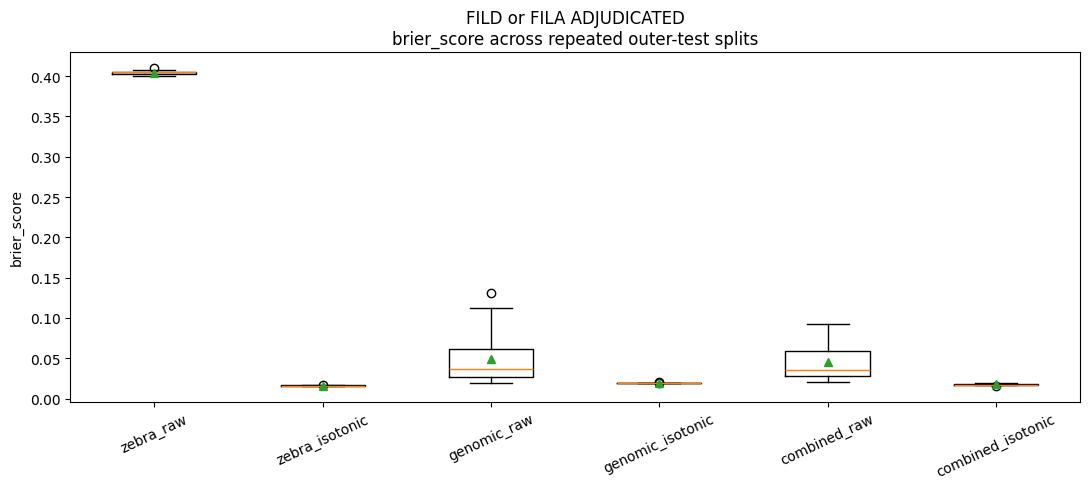

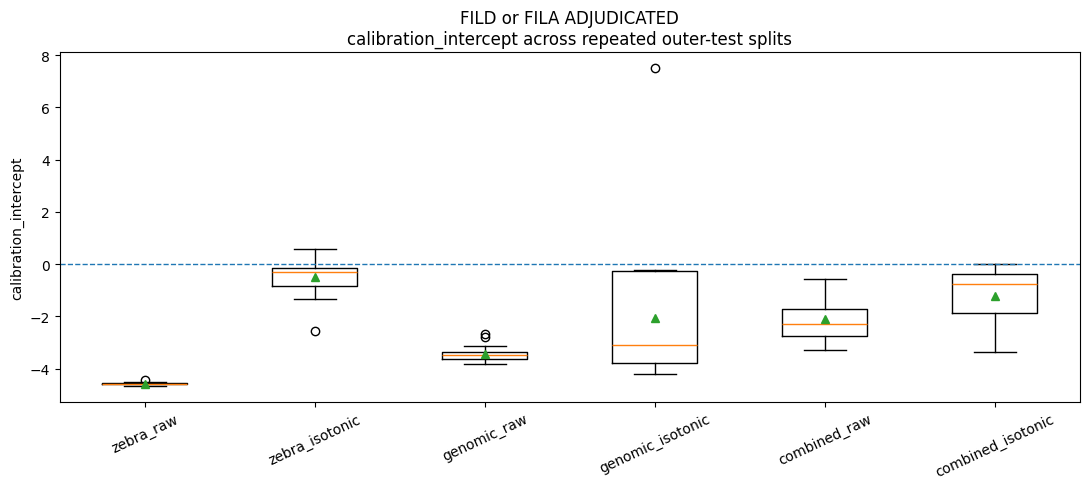

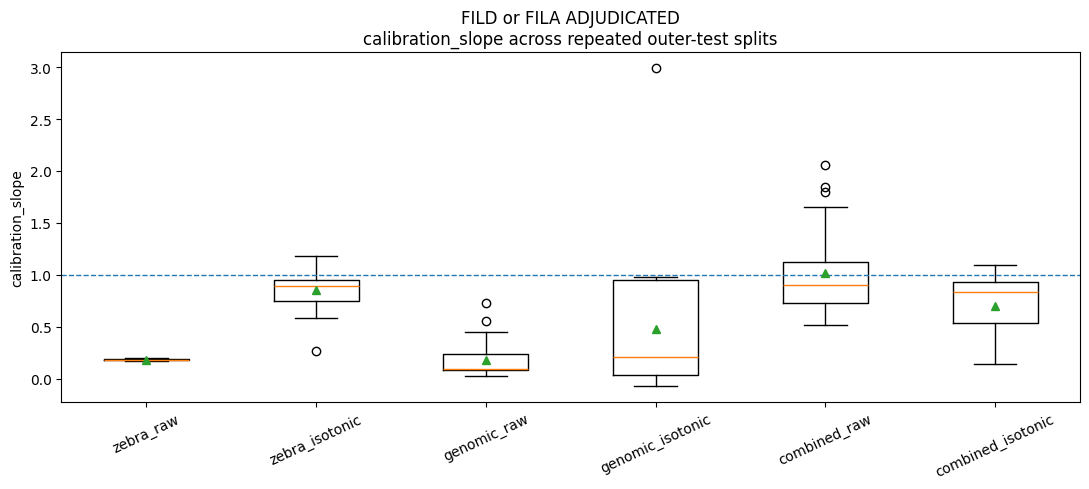

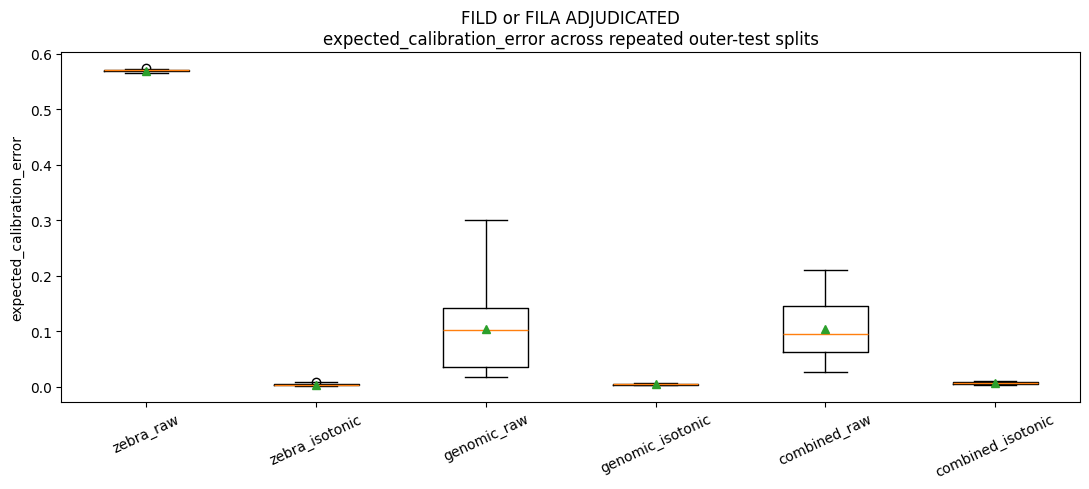

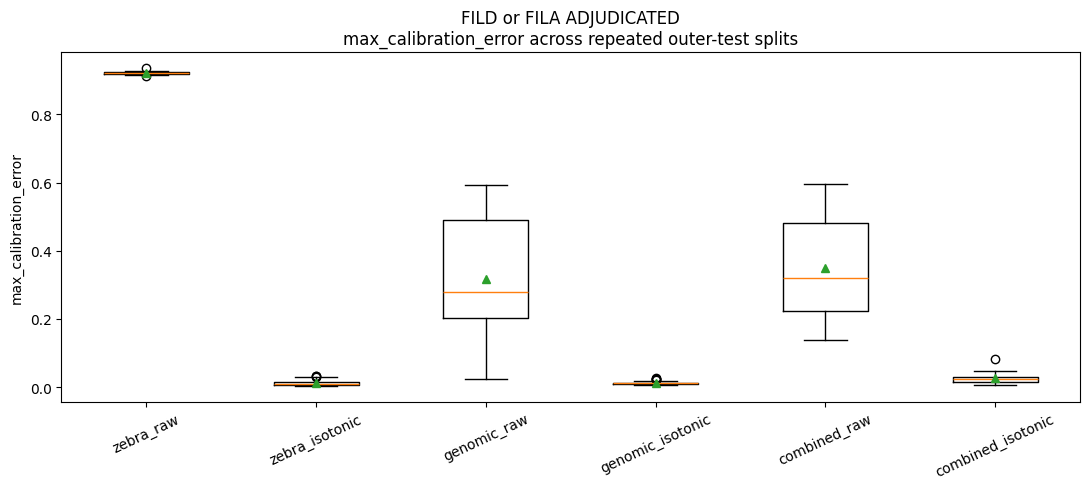

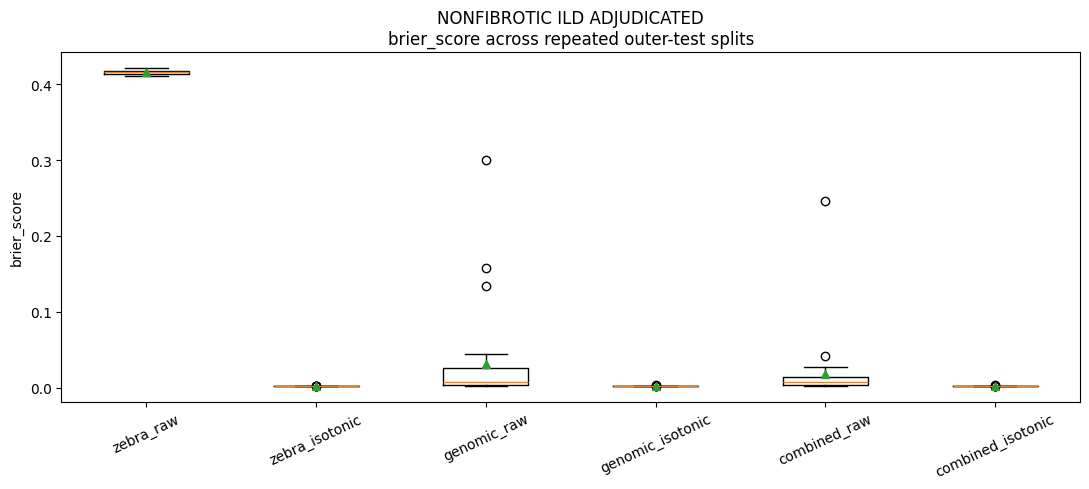

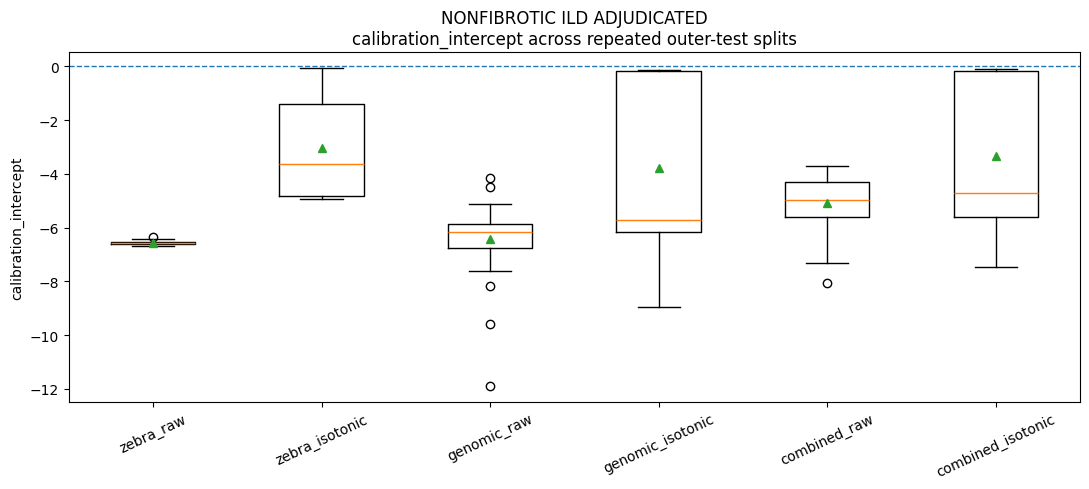

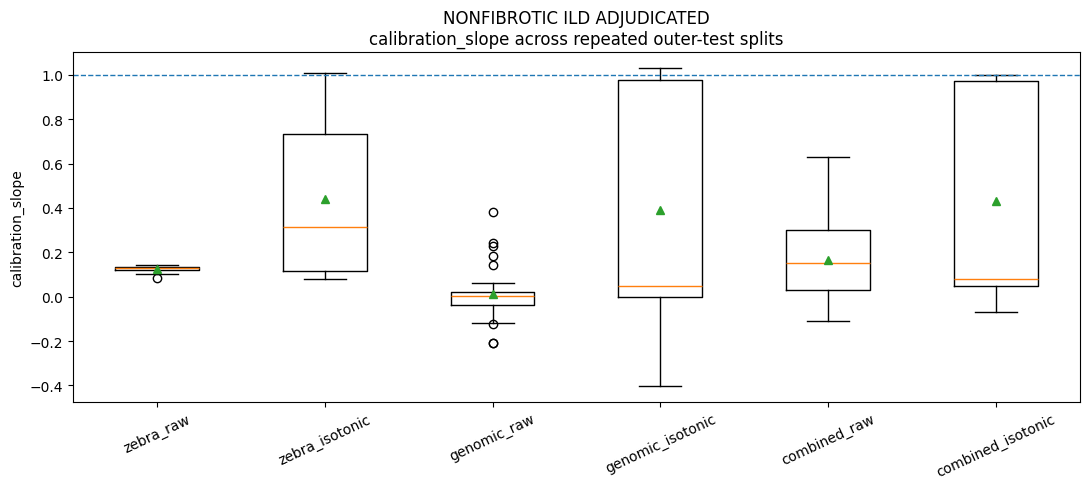

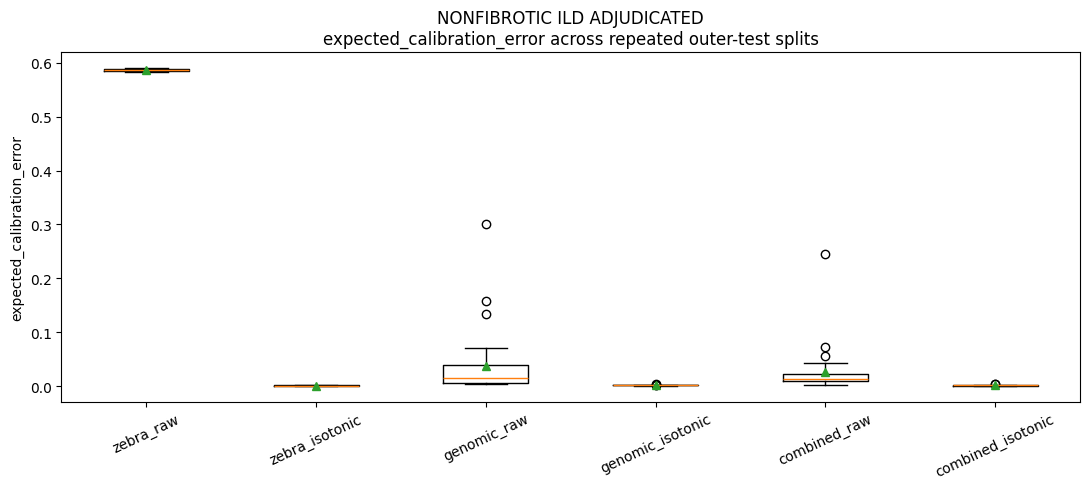

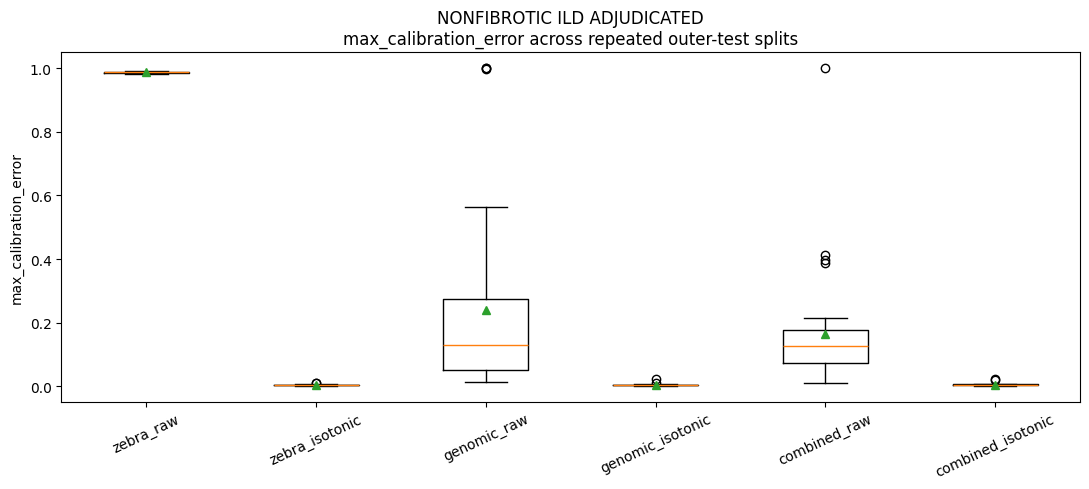

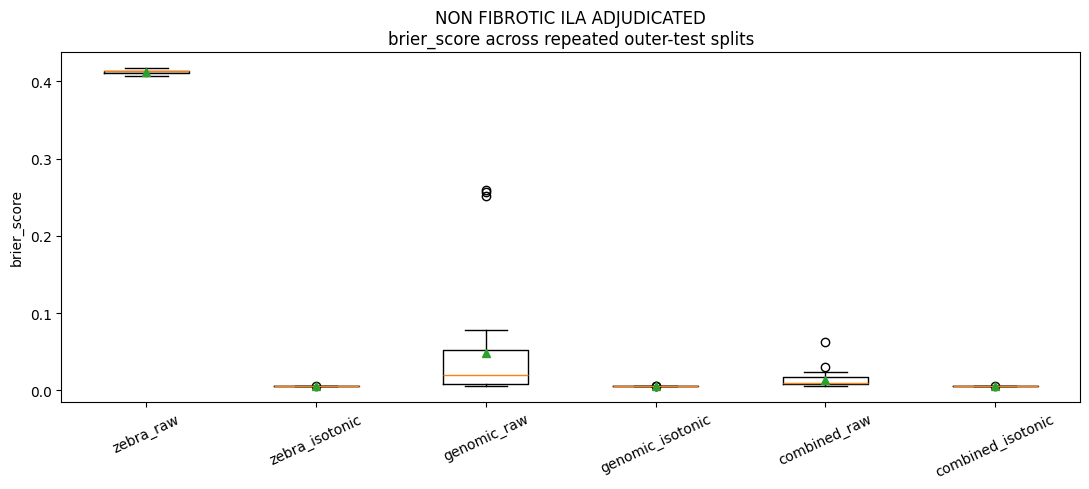

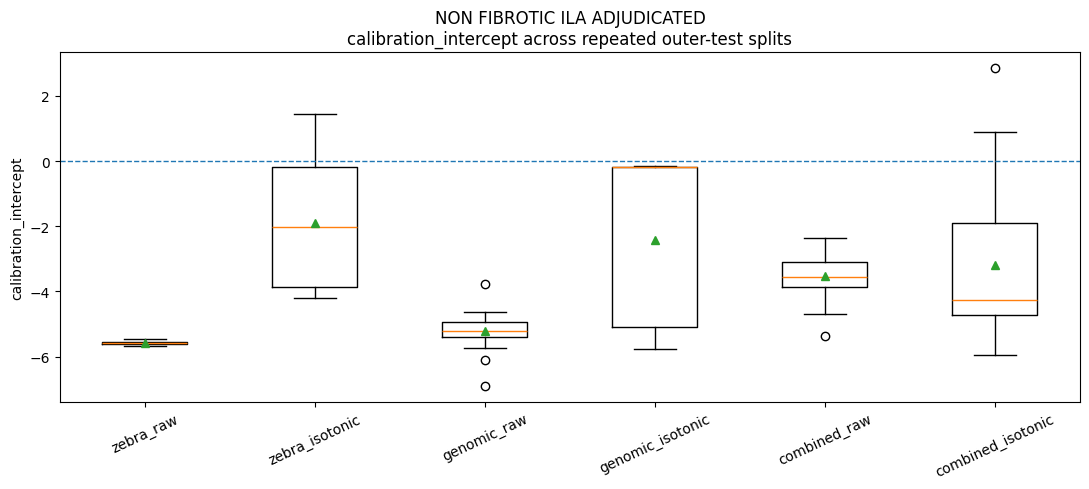

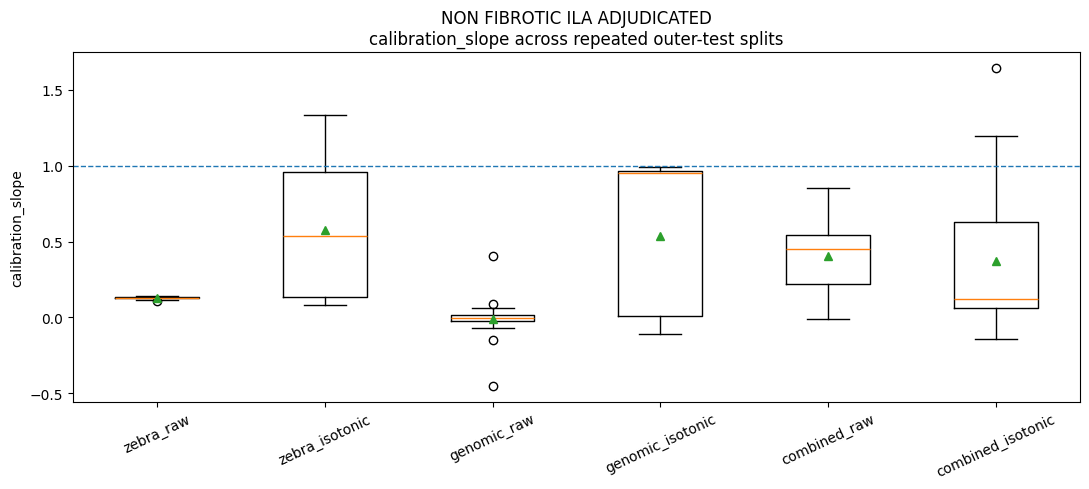

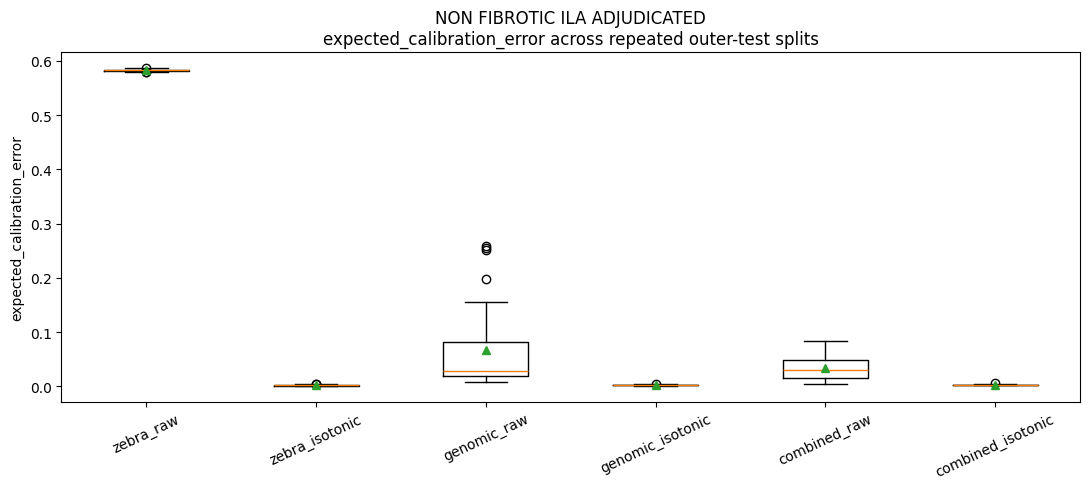

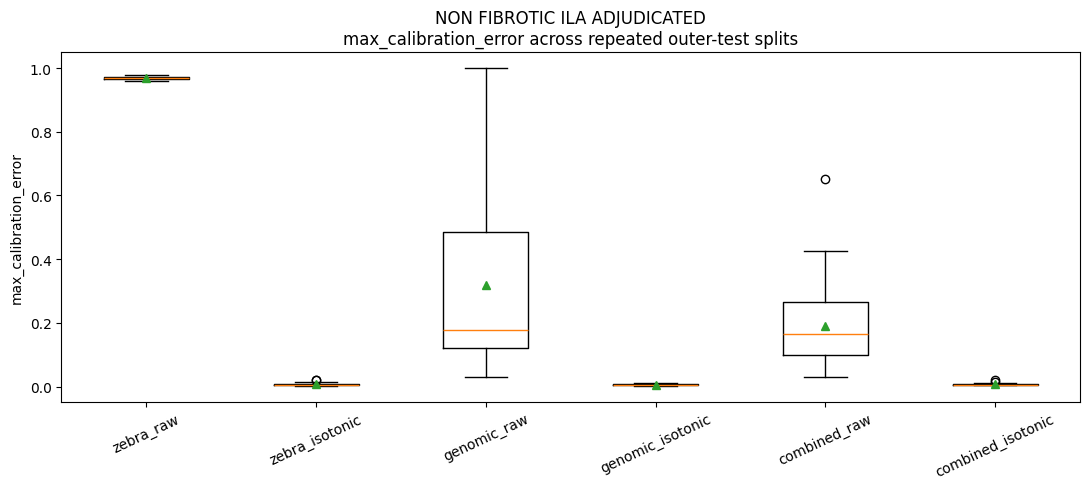

In [9]:
CAL_METRICS = [
    "brier_score",
    "calibration_intercept",
    "calibration_slope",
    "expected_calibration_error",
    "max_calibration_error",
]

MODEL_ORDER_CALIBRATION = [
    "zebra_raw",
    "zebra_isotonic",
    "genomic_raw",
    "genomic_isotonic",
    "combined_raw",
    "combined_isotonic",
]

for target_name in TARGET_NAMES:

    sub = ZEDSTAT_SUMMARY_DF[
        ZEDSTAT_SUMMARY_DF[
            "target_name"
        ] == target_name
    ]

    for metric in CAL_METRICS:

        fig, ax = plt.subplots(
            figsize=(11, 5)
        )

        data = [
            sub.loc[
                sub["model"] == model_name,
                metric,
            ].dropna().to_numpy()
            for model_name
            in MODEL_ORDER_CALIBRATION
        ]

        ax.boxplot(
            data,
            labels=MODEL_ORDER_CALIBRATION,
            showmeans=True,
        )

        if metric == "calibration_intercept":
            ax.axhline(
                0,
                linestyle="--",
                linewidth=1,
            )

        if metric == "calibration_slope":
            ax.axhline(
                1,
                linestyle="--",
                linewidth=1,
            )

        ax.set_ylabel(
            metric
        )
        ax.set_title(
            f"{target_name}\n"
            f"{metric} across repeated outer-test splits"
        )
        ax.tick_params(
            axis="x",
            labelrotation=25,
        )

        fig.tight_layout()

        safe_target = (
            target_name
            .replace("/", "_")
            .replace(" ", "_")
        )

        fig.savefig(
            ROOT_OUT
            / f"calibration_{metric}_{safe_target}.png",
            dpi=300,
            bbox_inches="tight",
        )

        plt.show()

## Plot AUC distributions for raw and isotonic variants

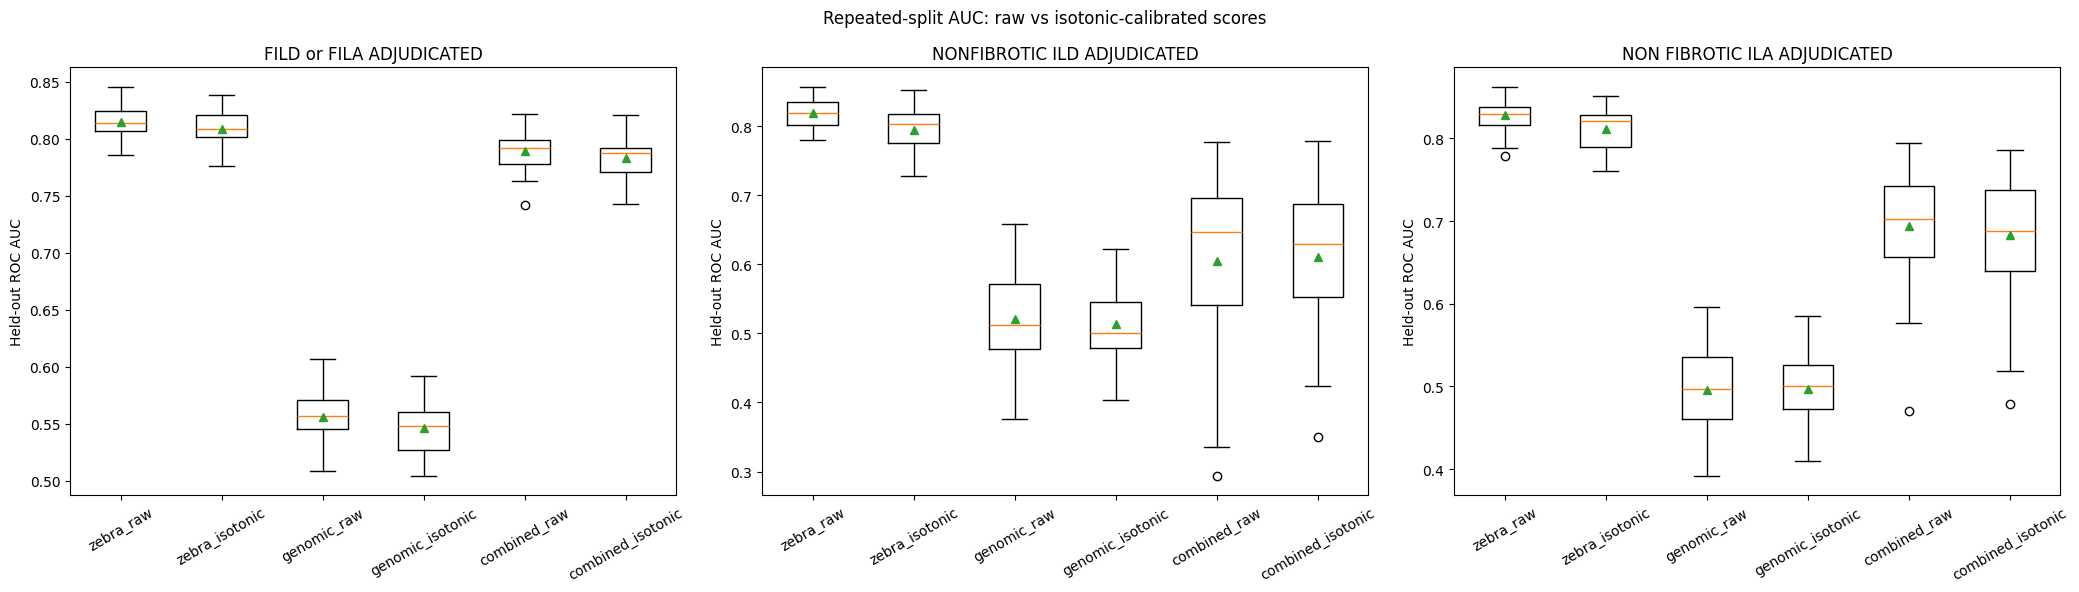

In [10]:
MODEL_ORDER = [
    "zebra_raw",
    "zebra_isotonic",
    "genomic_raw",
    "genomic_isotonic",
    "combined_raw",
    "combined_isotonic",
]

fig, axes = plt.subplots(
    1,
    len(TARGET_NAMES),
    figsize=(
        7 * len(TARGET_NAMES),
        6,
    ),
)

if len(TARGET_NAMES) == 1:
    axes = [axes]

for ax, target in zip(
    axes,
    TARGET_NAMES,
):
    sub = AUC_DF[
        AUC_DF[
            "target_name"
        ] == target
    ]

    values = [
        sub.loc[
            sub["model"] == model_name,
            "auc",
        ].to_numpy()
        for model_name
        in MODEL_ORDER
    ]

    ax.boxplot(
        values,
        labels=MODEL_ORDER,
        showmeans=True,
    )

    ax.set_title(
        target
    )
    ax.set_ylabel(
        "Held-out ROC AUC"
    )
    ax.tick_params(
        axis="x",
        labelrotation=30,
    )

fig.suptitle(
    "Repeated-split AUC: raw vs isotonic-calibrated scores"
)

fig.tight_layout()

fig.savefig(
    ROOT_OUT
    / "auc_distributions_raw_vs_isotonic.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

## How to interpret the calibrated comparison

The most important calibration result is not raw combined vs raw ZeBRA.

Use:

- `zebra_isotonic` as the calibrated ZeBRA reference;
- `combined_isotonic` as the calibrated multimodal model.

Then examine:

- Brier score;
- ECE;
- calibration intercept/slope;
- log-free probability calibration summaries;
- AUC separately as discrimination.

If `combined_isotonic` still improves Brier/ECE relative to `zebra_isotonic`,
that is evidence that genomics contributes to probabilistic prediction beyond
what can be explained by simply recalibrating ZeBRA.

In [11]:
KEY_MODELS = [
    "zebra_isotonic",
    "combined_isotonic",
]

KEY_METRICS = [
    "zedstat_auc",
    "brier_score",
    "expected_calibration_error",
    "calibration_intercept",
    "calibration_slope",
    "observed_to_expected_ratio",
]

KEY_SUMMARY = (
    ZEDSTAT_REPEATED_SUMMARY[
        ZEDSTAT_REPEATED_SUMMARY[
            "metric"
        ].isin(
            KEY_METRICS
        )
        &
        ZEDSTAT_REPEATED_SUMMARY[
            "model"
        ].isin(
            KEY_MODELS
        )
    ]
    .sort_values(
        [
            "target_name",
            "metric",
            "model",
        ]
    )
)

KEY_SUMMARY.to_csv(
    ROOT_OUT
    / "key_calibrated_zebra_vs_combined_summary.csv",
    index=False,
)

display(
    KEY_SUMMARY
)

display(
    FAIR_CALIBRATION_COMPARISON
)

,target_name,model,metric,n_repeats,mean,sd,median,q025,q975,min,max
53,FILD or FILA ADJUDICATED,combined_isotonic,brier_score,30,0.017466,0.000788,0.017419,0.016159,0.018878,0.015664,0.018977
13,FILD or FILA ADJUDICATED,zebra_isotonic,brier_score,30,0.016180,0.000408,0.016171,0.015660,0.017001,0.015637,0.017028
54,FILD or FILA ADJUDICATED,combined_isotonic,calibration_intercept,30,-1.227136,1.111915,-0.774063,-3.263646,-0.102661,-3.372125,0.010282
14,FILD or FILA ADJUDICATED,zebra_isotonic,calibration_intercept,30,-0.497225,0.599681,-0.287788,-1.678035,0.336394,-2.543115,0.593537
55,FILD or FILA ADJUDICATED,combined_isotonic,calibration_slope,30,0.703584,0.307527,0.836131,0.147094,1.065638,0.139578,1.094406
15,FILD or FILA ADJUDICATED,zebra_isotonic,calibration_slope,30,0.849007,0.179097,0.888396,0.495105,1.100533,0.266869,1.185165
56,FILD or FILA ADJUDICATED,combined_isotonic,expected_calibration_error,30,0.006575,0.002172,0.006811,0.003283,0.009957,0.002974,0.010606
16,FILD or FILA ADJUDICATED,zebra_isotonic,expected_calibration_error,30,0.004216,0.001840,0.003911,0.001930,0.008448,0.001623,0.009468
59,FILD or FILA ADJUDICATED,combined_isotonic,observed_to_expected_ratio,30,0.849775,0.103184,0.829529,0.698710,1.038159,0.695903,1.067028
19,FILD or FILA ADJUDICATED,zebra_isotonic,observed_to_expected_ratio,30,0.991195,0.054494,0.991111,0.897385,1.094506,0.892177,1.098626


,target_name,metric,comparison,n_repeats,mean_delta,median_delta,q025,q975,fraction_gt_zero,fraction_lt_zero
0,FILD or FILA ADJUDICATED,brier_score,combined_isotonic - zebra_isotonic,30,0.001286,0.001222,-0.000081,0.002873,0.933333,0.066667
1,FILD or FILA ADJUDICATED,expected_calibration_error,combined_isotonic - zebra_isotonic,30,0.002359,0.001795,-0.001005,0.006215,0.933333,0.066667
2,FILD or FILA ADJUDICATED,max_calibration_error,combined_isotonic - zebra_isotonic,30,0.012539,0.011354,-0.009749,0.043216,0.833333,0.166667
3,FILD or FILA ADJUDICATED,calibration_intercept,combined_isotonic - zebra_isotonic,30,-0.729912,-0.442433,-3.036579,1.089438,0.366667,0.633333
4,FILD or FILA ADJUDICATED,calibration_slope,combined_isotonic - zebra_isotonic,30,-0.145423,-0.079256,-0.781589,0.378406,0.466667,0.533333
5,FILD or FILA ADJUDICATED,mean_predicted_risk,combined_isotonic - zebra_isotonic,30,0.003584,0.003835,-0.000062,0.007540,0.966667,0.033333
6,FILD or FILA ADJUDICATED,observed_to_expected_ratio,combined_isotonic - zebra_isotonic,30,-0.141420,-0.154011,-0.296683,0.003209,0.033333,0.966667
7,NON FIBROTIC ILA ADJUDICATED,brier_score,combined_isotonic - zebra_isotonic,30,0.000071,0.000079,-0.000012,0.000128,0.966667,0.033333
8,NON FIBROTIC ILA ADJUDICATED,expected_calibration_error,combined_isotonic - zebra_isotonic,30,0.000799,0.000842,-0.000943,0.002414,0.833333,0.166667
9,NON FIBROTIC ILA ADJUDICATED,max_calibration_error,combined_isotonic - zebra_isotonic,30,0.000491,0.000500,-0.006852,0.006330,0.566667,0.433333


## Aggregate SHAP importance across splits

In [12]:
SHAP_DF = pd.concat(ALL_SHAP, ignore_index=True)

SHAP_DF.to_csv(
    ROOT_OUT / "shap_all_targets_by_split.csv",
    index=False,
)

SHAP_SUMMARY = shap_summary(SHAP_DF)

SHAP_SUMMARY.to_csv(
    ROOT_OUT / "shap_feature_stability_summary.csv",
    index=False,
)

display(
    SHAP_SUMMARY
    .sort_values(
        ["target_name", "model", "max_importance"],
        ascending=[True, True, False],
    )
    .groupby(["target_name", "model"], group_keys=False)
    .head(20)
)

,target_name,model,feature,n_splits,mean_importance,median_importance,max_importance,empirical_q025,empirical_q975,bootstrap_mean_ci_low,bootstrap_mean_ci_high,bootstrap_max_ci_low,bootstrap_max_ci_high
1026,FILD or FILA ADJUDICATED,combined,predicted_risk,30,0.795961,0.813582,1.215369,0.370515,1.173578,0.723241,0.868602,1.093329,1.215369
830,FILD or FILA ADJUDICATED,combined,rs35705950.1_G_2,30,0.128654,0.117491,0.330178,0.016970,0.293571,0.101195,0.157873,0.244137,0.330178
775,FILD or FILA ADJUDICATED,combined,rs1851741_G_1,30,0.027404,0.008751,0.321161,0.000000,0.138767,0.012211,0.051416,0.055923,0.321161
682,FILD or FILA ADJUDICATED,combined,rs13183751_G_1,30,0.077821,0.056456,0.306545,0.002832,0.305695,0.053452,0.108267,0.177694,0.306545
794,FILD or FILA ADJUDICATED,combined,rs34547036_C_2,30,0.057991,0.029340,0.287512,0.000000,0.253074,0.034423,0.085346,0.136626,0.287512
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1467,NONFIBROTIC ILD ADJUDICATED,genomic,rs1981997_G_2,30,69.198492,0.000000,1994.548705,0.000000,606.546518,0.029995,204.840603,0.220950,1994.548705
1500,NONFIBROTIC ILD ADJUDICATED,genomic,rs708686_C_2,30,68.088978,0.019643,1994.267840,0.000000,574.343886,0.211757,202.392375,5.292874,1994.267840
1470,NONFIBROTIC ILD ADJUDICATED,genomic,rs415430_T_2,30,65.085272,0.001108,1688.147469,0.000000,637.882910,0.063395,194.390271,0.720511,1688.147469
1100,NONFIBROTIC ILD ADJUDICATED,genomic,rs2361278_T_1,30,75.195420,0.000976,1430.480412,0.000000,985.605164,0.074045,204.293736,0.720970,1430.480412


## Plot maximum SHAP importance with bootstrap bounds

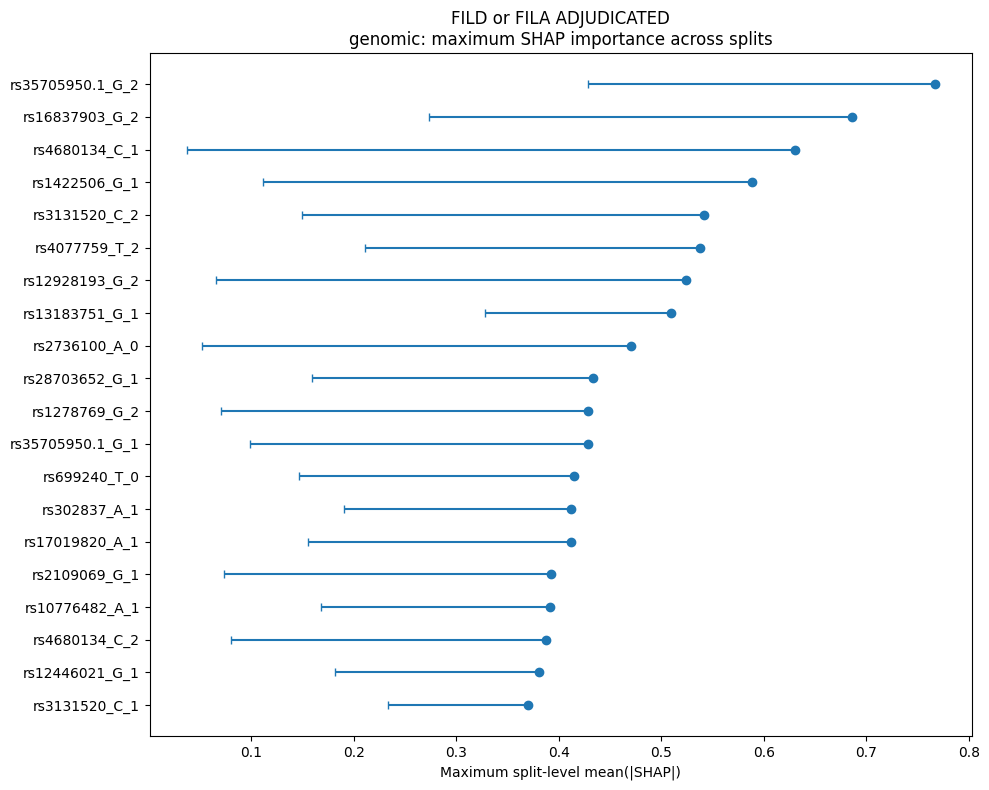

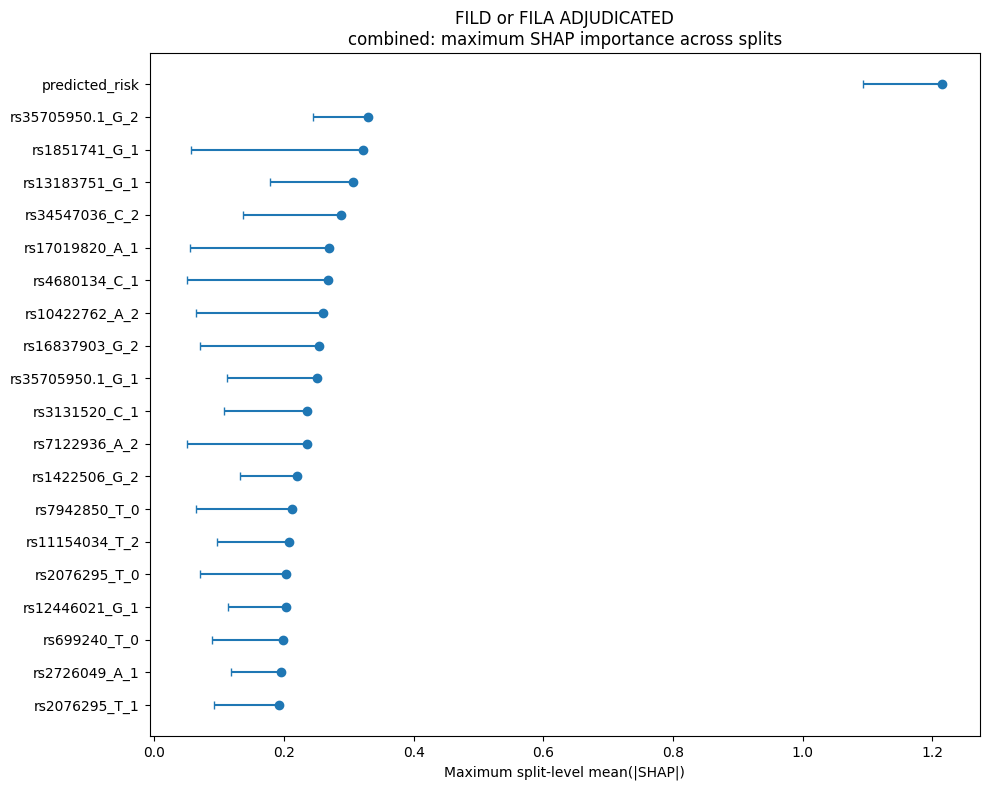

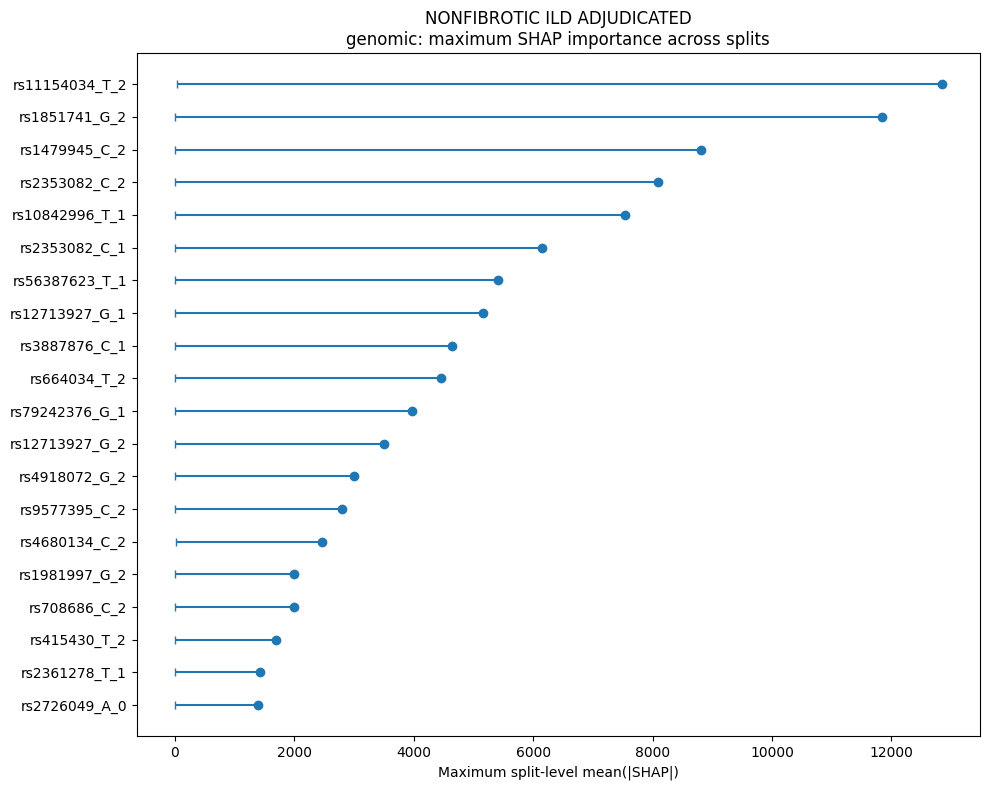

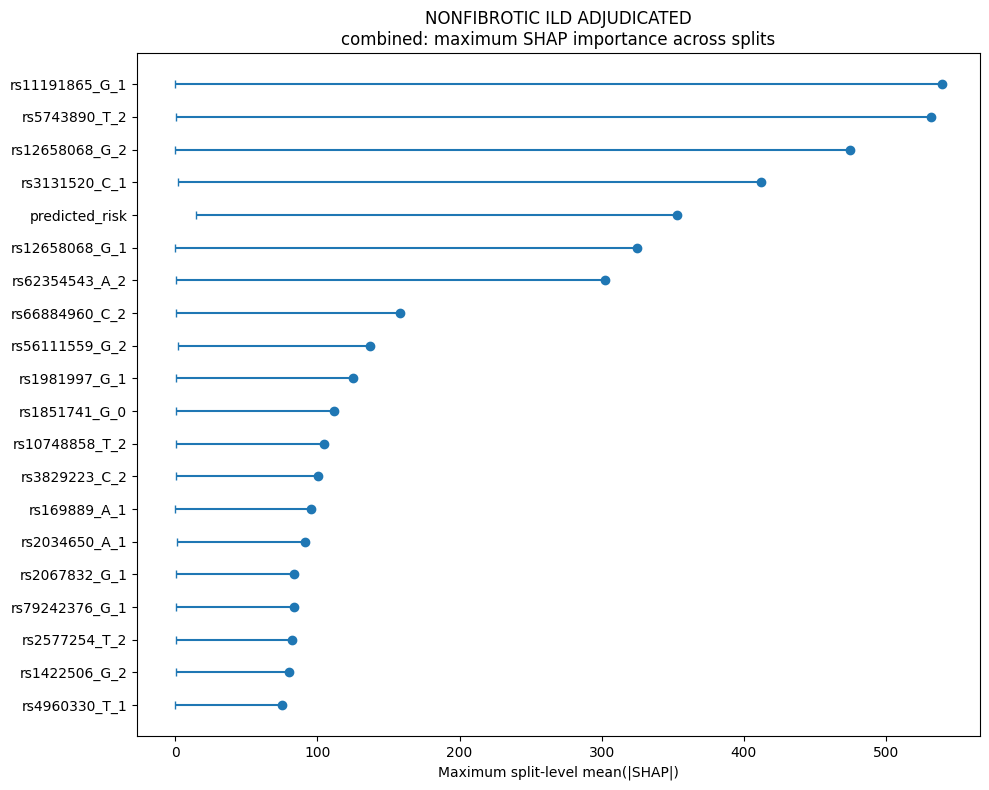

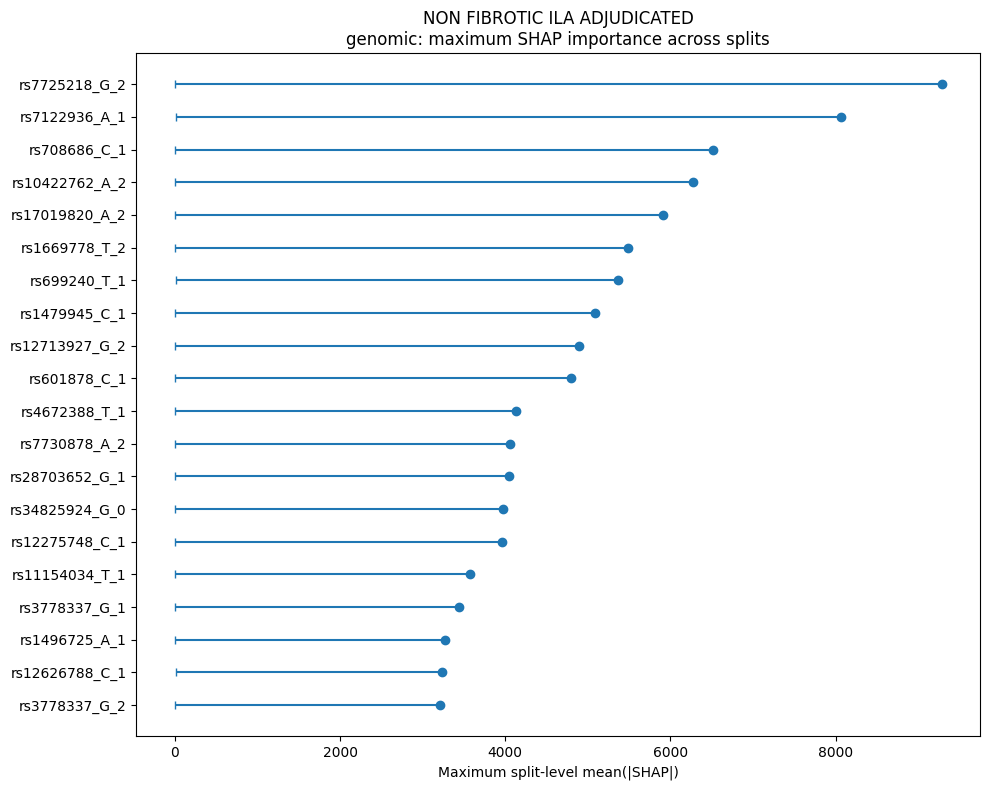

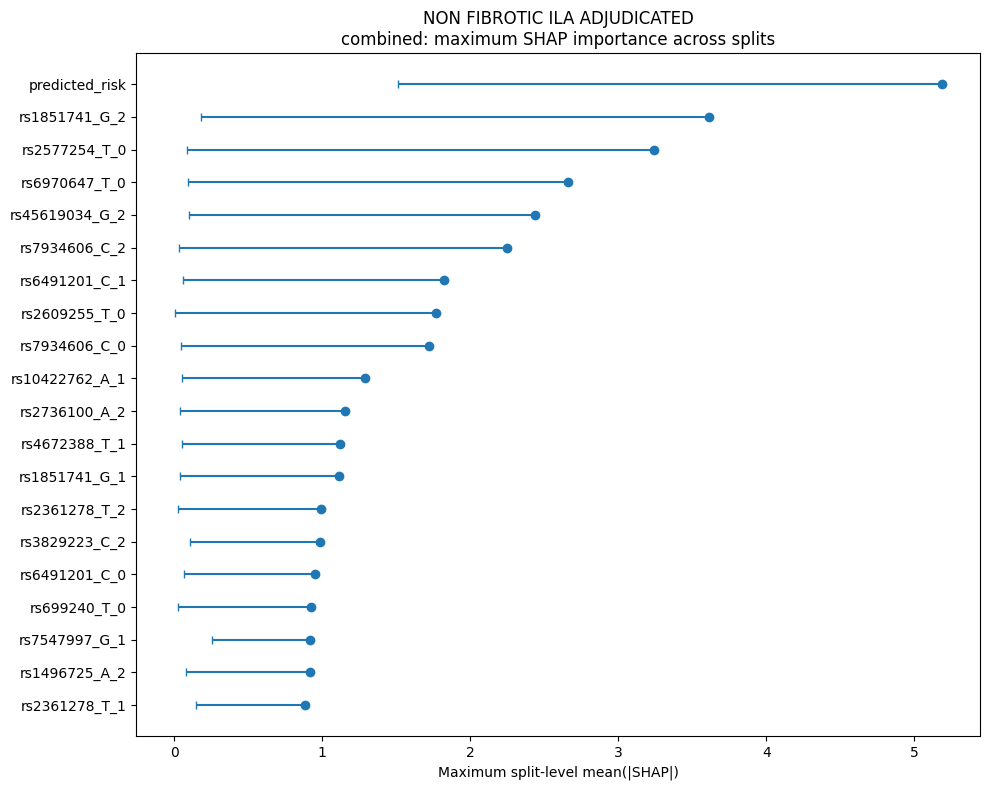

In [13]:
for target in TARGET_NAMES:
    for model in ["genomic", "combined"]:

        sub = (
            SHAP_SUMMARY[
                (SHAP_SUMMARY["target_name"] == target)
                & (SHAP_SUMMARY["model"] == model)
            ]
            .sort_values("max_importance", ascending=False)
            .head(20)
            .sort_values("max_importance")
        )

        x = sub["max_importance"].to_numpy()
        lo = sub["bootstrap_max_ci_low"].to_numpy()
        hi = sub["bootstrap_max_ci_high"].to_numpy()

        fig, ax = plt.subplots(figsize=(10, 8))

        ax.errorbar(
            x,
            np.arange(len(sub)),
            xerr=[
                np.maximum(x - lo, 0),
                np.maximum(hi - x, 0),
            ],
            fmt="o",
            capsize=3,
        )

        ax.set_yticks(np.arange(len(sub)))
        ax.set_yticklabels(sub["feature"])
        ax.set_xlabel("Maximum split-level mean(|SHAP|)")
        ax.set_title(
            f"{target}\n{model}: maximum SHAP importance across splits"
        )

        fig.tight_layout()
        fig.savefig(
            ROOT_OUT / target / f"shap_max_ci_{model}.png",
            dpi=300,
            bbox_inches="tight",
        )
        plt.show()

## Top-20 SHAP recurrence across splits

In [14]:
ranked = SHAP_DF.copy()

ranked["rank"] = (
    ranked.groupby(
        ["target_name", "model", "repeat"]
    )["mean_abs_shap"]
    .rank(method="min", ascending=False)
)

RECURRENCE = (
    ranked[ranked["rank"] <= 20]
    .groupby(["target_name", "model", "feature"])
    .agg(
        top20_split_count=("repeat", "nunique"),
        mean_rank_when_top20=("rank", "mean"),
        max_mean_abs_shap=("mean_abs_shap", "max"),
    )
    .reset_index()
)

RECURRENCE["fraction_splits_top20"] = (
    RECURRENCE["top20_split_count"] / N_REPEATS
)

RECURRENCE.to_csv(
    ROOT_OUT / "shap_top20_recurrence.csv",
    index=False,
)

display(
    RECURRENCE
    .sort_values(
        ["target_name", "model", "fraction_splits_top20", "max_mean_abs_shap"],
        ascending=[True, True, False, False],
    )
    .groupby(["target_name", "model"], group_keys=False)
    .head(25)
)

,target_name,model,feature,top20_split_count,mean_rank_when_top20,max_mean_abs_shap,fraction_splits_top20
0,FILD or FILA ADJUDICATED,combined,predicted_risk,30,1.000000,1.215369,1.000000
115,FILD or FILA ADJUDICATED,combined,rs35705950.1_G_2,26,4.692308,0.330178,0.866667
51,FILD or FILA ADJUDICATED,combined,rs1422506_G_2,16,11.125000,0.219700,0.533333
47,FILD or FILA ADJUDICATED,combined,rs13183751_G_1,15,7.666667,0.306545,0.500000
36,FILD or FILA ADJUDICATED,combined,rs12446021_G_2,12,6.583333,0.159422,0.400000
...,...,...,...,...,...,...,...
1763,NONFIBROTIC ILD ADJUDICATED,genomic,rs41482151_C_2,6,16.333333,0.215499,0.200000
1655,NONFIBROTIC ILD ADJUDICATED,genomic,rs1851741_G_2,5,8.400000,11845.911923,0.166667
1498,NONFIBROTIC ILD ADJUDICATED,genomic,rs10842996_T_1,5,13.400000,7537.000231,0.166667
1957,NONFIBROTIC ILD ADJUDICATED,genomic,rs79242376_G_1,5,13.800000,3967.693111,0.166667
